# Phase 4 — Policy Response, Retention Strategies, and Counterfactual Analysis

This notebook extends **Phase 3** from *forecasting what may happen* to **testing what Puerto Rico could do differently** to reduce future population loss.

## Core policy question

> Given the validated Phase 2 / Phase 3 forecasting backbone, which **actionable policy levers** appear most promising for improving population retention?

## Phase 4 purpose

Phase 4 does **not** claim causal proof. Instead, it uses the final validated **Lasso forecasting model** as a **policy stress-testing tool**:

- identify the **most policy-relevant features**
- define **counterfactual policy packages**
- estimate how those changes shift predicted population outcomes
- summarize results at the **municipal, regional, and island** levels

## Key idea

Natural disasters themselves are not preventable, but governments can still influence whether people **stay, return, or leave** by changing conditions such as:

- economic opportunity
- business activity
- public safety
- social vulnerability
- demographic and family-support conditions

This notebook turns those ideas into a reproducible **policy counterfactual framework**.


## Methodological note

This phase should be interpreted as a **predictive counterfactual exercise**, not a causal impact study.

That means:

- if the model learned that higher income growth, lower crime, and lower vulnerability are associated with better population outcomes,
- then we can simulate **what the model predicts** under improved values of those features.

This is useful for policy prioritization, but it is **not the same as proving** that a policy will cause the full predicted change in reality.


In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 140

OUTPUT_PREFIX = "phase4_policy"

PHASE4_DIR = Path("Phase4")
PHASE4_DATA_DIR = PHASE4_DIR / "data"
PHASE4_TABLE_DIR = PHASE4_DIR / "tables"
PHASE4_FIG_DIR = PHASE4_DIR / "figures"
PHASE4_MODEL_DIR = PHASE4_DIR / "models"
PHASE4_METADATA_DIR = PHASE4_DIR / "metadata"

for d in [PHASE4_DIR, PHASE4_DATA_DIR, PHASE4_TABLE_DIR, PHASE4_FIG_DIR, PHASE4_MODEL_DIR, PHASE4_METADATA_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Phase 4 output directory:", PHASE4_DIR.resolve())
print("  data:", PHASE4_DATA_DIR.resolve())
print("  tables:", PHASE4_TABLE_DIR.resolve())
print("  figures:", PHASE4_FIG_DIR.resolve())
print("  models:", PHASE4_MODEL_DIR.resolve())
print("  metadata:", PHASE4_METADATA_DIR.resolve())


Phase 4 output directory: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/Phase4
  data: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/Phase4/data
  tables: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/Phase4/tables
  figures: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/Phase4/figures
  models: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/Phase4/models
  metadata: /Users/andreruiz/Documents/Capstone/CAPSTONE_DATA_SCIENCE_RIVERARUIZ/population_analysis/Phase4/metadata


## Output folder

All Phase 4 files generated by this notebook are saved into a dedicated folder named **`Phase4`** using the same structured layout established in earlier phases:

- `Phase4/data`
- `Phase4/tables`
- `Phase4/figures`
- `Phase4/models`
- `Phase4/metadata`

This keeps policy outputs reproducible and clearly separated from the Phase 1, Phase 2, and Phase 3 artifacts.


In [2]:
# ----------------------------
# File location helpers
# ----------------------------
def first_existing_path(candidates):
    for p in candidates:
        path = Path(p)
        if path.exists():
            return path
    return None

PHASE1_DATA_CANDIDATES = [
    "Phase1/data/processed_puerto_rico_data_rebuild.csv",
    "Phase1/data/processed_puerto_rico_data_enriched.csv",
    "../Phase1/data/processed_puerto_rico_data_rebuild.csv",
    "../Phase1/data/processed_puerto_rico_data_enriched.csv",
    "../data/processed_puerto_rico_data_rebuild.csv",
    "../data/processed_puerto_rico_data_enriched.csv",
    "processed_puerto_rico_data_rebuild.csv",
    "processed_puerto_rico_data_enriched.csv",
]

PHASE3_PIPELINE_CANDIDATES = [
    "Phase3/models/phase3_v7_backbone_pipeline.joblib",
    "Phase3/models/phase3_v6_backbone_pipeline.joblib",
    "../Phase3/models/phase3_v7_backbone_pipeline.joblib",
    "../Phase3/models/phase3_v6_backbone_pipeline.joblib",
]

PHASE2_PIPELINE_CANDIDATES = [
    "Phase2/models/phase2_v12_best_pipeline.joblib",
    "Phase2/models/phase2_v11_best_pipeline.joblib",
    "Phase2/models/phase2_v10_best_pipeline.joblib",
    "../Phase2/models/phase2_v12_best_pipeline.joblib",
    "../Phase2/models/phase2_v11_best_pipeline.joblib",
    "../Phase2/models/phase2_v10_best_pipeline.joblib",
    "phase2_v12_best_pipeline.joblib",
    "phase2_v11_best_pipeline.joblib",
    "phase2_v10_best_pipeline.joblib",
]

PHASE2_SUMMARY_CANDIDATES = [
    "Phase2/metadata/phase2_v12_best_model_summary.json",
    "Phase2/metadata/phase2_v11_best_model_summary.json",
    "Phase2/metadata/phase2_v10_best_model_summary.json",
    "../Phase2/metadata/phase2_v12_best_model_summary.json",
    "../Phase2/metadata/phase2_v11_best_model_summary.json",
    "../Phase2/metadata/phase2_v10_best_model_summary.json",
    "phase2_v12_best_model_summary.json",
    "phase2_v11_best_model_summary.json",
    "phase2_v10_best_model_summary.json",
]

PHASE3_SUMMARY_CANDIDATES = [
    "Phase3/metadata/phase3_v7_backbone_model_summary.json",
    "Phase3/metadata/phase3_v6_backbone_model_summary.json",
    "../Phase3/metadata/phase3_v7_backbone_model_summary.json",
    "../Phase3/metadata/phase3_v6_backbone_model_summary.json",
    "phase3_v7_backbone_model_summary.json",
    "phase3_v6_backbone_model_summary.json",
]

data_path = first_existing_path(PHASE1_DATA_CANDIDATES)
phase3_pipeline_path = first_existing_path(PHASE3_PIPELINE_CANDIDATES)
phase4_backbone_pipeline_path = first_existing_path(PHASE2_PIPELINE_CANDIDATES)
pipeline_path = phase3_pipeline_path or phase4_backbone_pipeline_path
phase2_summary_path = first_existing_path(PHASE2_SUMMARY_CANDIDATES)
phase3_summary_path = first_existing_path(PHASE3_SUMMARY_CANDIDATES)

print("Phase 1 data path:", data_path)
print("Phase 3 backbone pipeline:", phase3_pipeline_path)
print("Phase 2 fallback pipeline:", phase4_backbone_pipeline_path)
print("Selected pipeline path:", pipeline_path)
print("Phase 2 summary:", phase2_summary_path)
print("Phase 3 summary:", phase3_summary_path)

if data_path is None:
    raise FileNotFoundError("Could not find Phase 1 processed Puerto Rico dataset.")
if pipeline_path is None:
    raise FileNotFoundError("Could not find Phase 3 backbone pipeline or Phase 2 fallback pipeline.")

phase4_input_manifest = {
    "phase1_data_path": str(data_path),
    "phase3_pipeline_path": str(phase3_pipeline_path) if phase3_pipeline_path is not None else None,
    "phase2_fallback_pipeline_path": str(phase4_backbone_pipeline_path) if phase4_backbone_pipeline_path is not None else None,
    "selected_pipeline_path": str(pipeline_path),
    "phase2_summary_path": str(phase2_summary_path) if phase2_summary_path is not None else None,
    "phase3_summary_path": str(phase3_summary_path) if phase3_summary_path is not None else None,
}

manifest_path = PHASE4_METADATA_DIR / f"{OUTPUT_PREFIX}_input_manifest.json"
manifest_path.write_text(json.dumps(phase4_input_manifest, indent=2))
print("Saved input manifest:", manifest_path)


Phase 1 data path: Phase1/data/processed_puerto_rico_data_rebuild.csv
Phase 3 backbone pipeline: Phase3/models/phase3_v7_backbone_pipeline.joblib
Phase 2 fallback pipeline: Phase2/models/phase2_v12_best_pipeline.joblib
Selected pipeline path: Phase3/models/phase3_v7_backbone_pipeline.joblib
Phase 2 summary: Phase2/metadata/phase2_v12_best_model_summary.json
Phase 3 summary: Phase3/metadata/phase3_v7_backbone_model_summary.json
Saved input manifest: Phase4/metadata/phase4_policy_input_manifest.json


In [3]:
# ----------------------------
# Canonical Puerto Rico region helpers
# ----------------------------
import unicodedata

PR_REGION_MAP = {
    # Metro
    "San Juan": "Metro", "Bayamón": "Metro", "Carolina": "Metro", "Cataño": "Metro",
    "Guaynabo": "Metro", "Toa Alta": "Metro", "Toa Baja": "Metro", "Trujillo Alto": "Metro",

    # North
    "Arecibo": "North", "Barceloneta": "North", "Camuy": "North", "Dorado": "North",
    "Florida": "North", "Hatillo": "North", "Manatí": "North", "Quebradillas": "North",
    "Vega Alta": "North", "Vega Baja": "North",

    # South
    "Arroyo": "South", "Coamo": "South", "Guayama": "South", "Guayanilla": "South",
    "Juana Díaz": "South", "Patillas": "South", "Peñuelas": "South", "Ponce": "South",
    "Salinas": "South", "Santa Isabel": "South", "Villalba": "South", "Yauco": "South",

    # West
    "Aguada": "West", "Aguadilla": "West", "Añasco": "West", "Cabo Rojo": "West",
    "Guánica": "West", "Hormigueros": "West", "Isabela": "West", "Lajas": "West",
    "Las Marías": "West", "Maricao": "West", "Mayagüez": "West", "Moca": "West",
    "Rincón": "West", "Sabana Grande": "West", "San Germán": "West", "San Sebastián": "West",

    # East
    "Canóvanas": "East", "Ceiba": "East", "Fajardo": "East", "Humacao": "East",
    "Juncos": "East", "Las Piedras": "East", "Loíza": "East", "Luquillo": "East",
    "Maunabo": "East", "Naguabo": "East", "Río Grande": "East", "San Lorenzo": "East",
    "Yabucoa": "East", "Caguas": "East", "Gurabo": "East", "Culebra": "East", "Vieques": "East",

    # Central Mountains
    "Adjuntas": "Central Mountains", "Aguas Buenas": "Central Mountains", "Aibonito": "Central Mountains",
    "Barranquitas": "Central Mountains", "Cayey": "Central Mountains", "Ciales": "Central Mountains",
    "Cidra": "Central Mountains", "Comerío": "Central Mountains", "Corozal": "Central Mountains",
    "Jayuya": "Central Mountains", "Lares": "Central Mountains", "Morovis": "Central Mountains",
    "Naranjito": "Central Mountains", "Orocovis": "Central Mountains", "Utuado": "Central Mountains",
}

REGION_ALIASES = {
    "metro": "Metro",
    "metropolitan": "Metro",
    "san juan metro": "Metro",
    "north": "North",
    "norte": "North",
    "northern": "North",
    "south": "South",
    "sur": "South",
    "southern": "South",
    "west": "West",
    "oeste": "West",
    "western": "West",
    "east": "East",
    "este": "East",
    "eastern": "East",
    "central mountains": "Central Mountains",
    "central": "Central Mountains",
    "center": "Central Mountains",
    "mountains": "Central Mountains",
    "montanas centrales": "Central Mountains",
    "montanas central": "Central Mountains",
    "central mountain": "Central Mountains",
}

BAD_REGION_TOKENS = {"", "0", "0.0", "nan", "none", "null", "na", "n/a", "unknown", "unassigned"}

def _normalize_text(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    if not x:
        return None
    x = unicodedata.normalize("NFKD", x).encode("ascii", "ignore").decode("utf-8")
    x = " ".join(x.split())
    return x

PR_REGION_MAP_NORM = {_normalize_text(k).lower(): v for k, v in PR_REGION_MAP.items()}

def canonical_region_value(x):
    if pd.isna(x):
        return np.nan
    raw = _normalize_text(x)
    if raw is None:
        return np.nan
    low = raw.lower()
    if low in BAD_REGION_TOKENS:
        return np.nan
    if low in REGION_ALIASES:
        return REGION_ALIASES[low]
    return raw.title()

def canonical_municipio_value(x):
    raw = _normalize_text(x)
    return raw if raw is not None else np.nan

def infer_region_from_municipio(x):
    raw = _normalize_text(x)
    if raw is None:
        return np.nan
    return PR_REGION_MAP_NORM.get(raw.lower(), np.nan)

def ensure_region_column(frame, municipio_col="municipio", region_col="region"):
    frame = frame.copy()

    if municipio_col in frame.columns:
        frame[municipio_col] = frame[municipio_col].apply(canonical_municipio_value)

    if region_col not in frame.columns:
        frame[region_col] = np.nan

    frame[region_col] = frame[region_col].apply(canonical_region_value)

    if municipio_col in frame.columns:
        inferred = frame[municipio_col].apply(infer_region_from_municipio)
        frame[region_col] = frame[region_col].fillna(inferred)

    return frame

def valid_region_list(series):
    vals = pd.Series(series).dropna().astype(str).map(lambda x: canonical_region_value(x))
    vals = vals.dropna().astype(str)
    return sorted(pd.unique(vals).tolist())

In [4]:
# ----------------------------
# Load data and final model
# ----------------------------
df = pd.read_csv(data_path)
phase4_backbone_pipeline = joblib.load(pipeline_path)

phase2_summary = {}
if phase2_summary_path is not None:
    phase2_summary = json.loads(Path(phase2_summary_path).read_text())

phase3_summary = {}
if phase3_summary_path is not None:
    phase3_summary = json.loads(Path(phase3_summary_path).read_text())

# Bring Phase 4 cleanup in line with the Phase 3 backbone notebook
rename_candidates = {
    "municipality": "municipio",
    "Municipio": "municipio",
    "Municipality": "municipio",
    "Region": "region",
    "Year": "year",
    "total_pop": "total_population",
    "population": "total_population",
}
for old, new in rename_candidates.items():
    if old in df.columns and new not in df.columns:
        df = df.rename(columns={old: new})

if "municipio" not in df.columns:
    raise KeyError("Expected a 'municipio' column.")
if "year" not in df.columns:
    raise KeyError("Expected a 'year' column.")
if "total_population" not in df.columns:
    pop_candidates = [c for c in df.columns if "population" in c.lower()]
    if not pop_candidates:
        raise KeyError("Could not identify total population column.")
    df["total_population"] = pd.to_numeric(df[pop_candidates[0]], errors="coerce")

df = ensure_region_column(df, municipio_col="municipio", region_col="region")
df["year"] = pd.to_numeric(df["year"], errors="coerce")
df["total_population"] = pd.to_numeric(df["total_population"], errors="coerce")
df = df.dropna(subset=["municipio", "year", "total_population"]).copy()
df["year"] = df["year"].astype(int)
df = df.sort_values(["municipio", "year"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Columns:", len(df.columns))
print("Canonical regions present:", valid_region_list(df["region"]))

if hasattr(phase4_backbone_pipeline, "feature_names_in_"):
    feature_cols = list(phase4_backbone_pipeline.feature_names_in_)
else:
    feature_cols = [c for c in df.columns if c not in {"target_pop_change_3y_avg"}]

target_col = "target_pop_change_3y_avg"
print("Target:", target_col)
print("Feature count expected by pipeline:", len(feature_cols))

def get_model_feature_diagnostics(pipeline):
    pre_key = next((k for k in pipeline.named_steps if "pre" in k), None)
    model_key = next((k for k in pipeline.named_steps if "model" in k), None)
    if pre_key is None or model_key is None:
        raise KeyError(f"Could not identify preprocessing/model steps in pipeline: {list(pipeline.named_steps.keys())}")
    pre = pipeline.named_steps[pre_key]
    model = pipeline.named_steps[model_key]
    transformed_names = list(pre.get_feature_names_out())
    coefs = np.asarray(model.coef_)

    rows = []
    for transformed_name, coef in zip(transformed_names, coefs):
        if "__" in transformed_name:
            feature_block, raw_feature = transformed_name.split("__", 1)
        else:
            feature_block, raw_feature = "unknown", transformed_name

        is_active = bool(np.abs(coef) > 1e-10)
        rows.append({
            "transformed_feature": transformed_name,
            "feature_block": feature_block,
            "feature": raw_feature,
            "coefficient": float(coef),
            "abs_coefficient": float(abs(coef)),
            "is_active": is_active,
        })

    out = pd.DataFrame(rows).sort_values(["is_active", "abs_coefficient"], ascending=[False, False]).reset_index(drop=True)
    return out

model_feature_df = get_model_feature_diagnostics(phase4_backbone_pipeline)
model_feature_df.to_csv(PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_model_feature_diagnostics.csv", index=False)

active_model_features = model_feature_df.loc[model_feature_df["is_active"], "feature"].tolist()
active_numeric_features = model_feature_df.loc[
    model_feature_df["is_active"] & (model_feature_df["feature_block"] == "num"),
    "feature"
].tolist()
feature_coef_map = (
    model_feature_df.drop_duplicates(subset=["feature"])
    .set_index("feature")["coefficient"]
    .to_dict()
)

print("Active transformed features:", int(model_feature_df["is_active"].sum()))
print("Active numeric features:", active_numeric_features)

pipeline_copy_path = PHASE4_MODEL_DIR / f"{OUTPUT_PREFIX}_backbone_pipeline.joblib"
joblib.dump(phase4_backbone_pipeline, pipeline_copy_path)
print("Saved Phase 4 backbone pipeline copy:", pipeline_copy_path)

backbone_meta = {
    "selected_pipeline_path": str(pipeline_path),
    "copied_pipeline_path": str(pipeline_copy_path),
    "phase2_summary_path": str(phase2_summary_path) if phase2_summary_path is not None else None,
    "phase3_summary_path": str(phase3_summary_path) if phase3_summary_path is not None else None,
    "dataset_shape": [int(df.shape[0]), int(df.shape[1])],
    "feature_count_expected_by_pipeline": int(len(feature_cols)),
}
backbone_meta_path = PHASE4_METADATA_DIR / f"{OUTPUT_PREFIX}_backbone_metadata.json"
backbone_meta_path.write_text(json.dumps(backbone_meta, indent=2))
print("Saved backbone metadata:", backbone_meta_path)


Dataset shape: (1170, 168)
Columns: 168
Canonical regions present: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']
Target: target_pop_change_3y_avg
Feature count expected by pipeline: 50
Active transformed features: 4
Active numeric features: ['target_pop_change_3y_avg_lag1', 'target_pop_change_3y_avg_yoy_change', 'year', 'natural_change_rate_pr_lag1']
Saved Phase 4 backbone pipeline copy: Phase4/models/phase4_policy_backbone_pipeline.joblib
Saved backbone metadata: Phase4/metadata/phase4_policy_backbone_metadata.json


## Final backbone carried into Phase 4

This notebook uses the **same validated forecasting backbone** carried from Phase 2 into Phase 3. It now **prefers the saved Phase 3 backbone pipeline artifact** from `Phase3/models/` and falls back to the final Phase 2 pipeline only if the Phase 3 artifact is unavailable.

If the summary files are present below, they provide a direct record of the validation/test performance used as the basis for policy counterfactuals.


In [5]:
backbone_rows = []

if phase2_summary:
    backbone_rows.append({
        "source": "Phase 2 final summary",
        "model": phase2_summary.get("model", "unknown"),
        "validation_r2": phase2_summary.get("val_r2"),
        "test_r2": phase2_summary.get("test_r2"),
        "test_rmse": phase2_summary.get("test_rmse"),
    })

if phase3_summary:
    backbone_rows.append({
        "source": "Phase 3 backbone summary",
        "model": phase3_summary.get("model", "unknown"),
        "validation_r2": phase3_summary.get("metrics", {}).get("validation", {}).get("r2"),
        "test_r2": phase3_summary.get("metrics", {}).get("test", {}).get("r2"),
        "test_rmse": phase3_summary.get("metrics", {}).get("test", {}).get("rmse"),
    })

backbone_df = pd.DataFrame(backbone_rows)
backbone_df


,source,model,validation_r2,test_r2,test_rmse
0,Phase 2 final summary,lasso,0.952612,0.909249,0.453066
1,Phase 3 backbone summary,lasso,0.952612,0.909249,0.453066


## Step 1 — Build the latest policy baseline

We take the **latest observed row for each municipio** and use it as the Phase 4 baseline, but we do **not** blindly zero-fill missing model features.

Instead, the notebook now reconstructs missing baseline inputs in a more faithful way:

- first, carry forward the **last valid municipio-level value** already present in the historical panel
- second, derive common lag / rolling / year-over-year features from observed history when possible
- only then use conservative fallback fills for any truly unresolved values

That keeps Phase 4 aligned with the validated Phase 2 feature space and avoids flat policy results caused by incomplete inputs.

In [6]:
# Keep the latest available row per municipio
required_base_cols = ["municipio", "region", "year", "total_population"]

def _derive_feature_from_history(group, feature_name):
    if feature_name not in group.columns:
        if feature_name.endswith("_lag1"):
            root = feature_name[:-5]
            if root in group.columns:
                vals = pd.to_numeric(group[root], errors="coerce").dropna()
                if len(vals) >= 2:
                    return vals.iloc[-2]
        elif feature_name.endswith("_lag2"):
            root = feature_name[:-5]
            if root in group.columns:
                vals = pd.to_numeric(group[root], errors="coerce").dropna()
                if len(vals) >= 3:
                    return vals.iloc[-3]
        elif feature_name.endswith("_roll3_mean"):
            root = feature_name[:-11]
            if root in group.columns:
                vals = pd.to_numeric(group[root], errors="coerce").dropna()
                if len(vals) >= 1:
                    return vals.iloc[-3:].mean()
        elif feature_name.endswith("_yoy_change"):
            root = feature_name[:-11]
            if root in group.columns:
                vals = pd.to_numeric(group[root], errors="coerce").dropna()
                if len(vals) >= 2:
                    return vals.iloc[-1] - vals.iloc[-2]
        return np.nan

    series = pd.to_numeric(group[feature_name], errors="coerce").dropna()
    if len(series) >= 1:
        return series.iloc[-1]

    # Fallback to suffix-based derivation from root feature history
    if feature_name.endswith("_lag1"):
        root = feature_name[:-5]
        if root in group.columns:
            vals = pd.to_numeric(group[root], errors="coerce").dropna()
            if len(vals) >= 2:
                return vals.iloc[-2]
    elif feature_name.endswith("_lag2"):
        root = feature_name[:-5]
        if root in group.columns:
            vals = pd.to_numeric(group[root], errors="coerce").dropna()
            if len(vals) >= 3:
                return vals.iloc[-3]
    elif feature_name.endswith("_roll3_mean"):
        root = feature_name[:-11]
        if root in group.columns:
            vals = pd.to_numeric(group[root], errors="coerce").dropna()
            if len(vals) >= 1:
                return vals.iloc[-3:].mean()
    elif feature_name.endswith("_yoy_change"):
        root = feature_name[:-11]
        if root in group.columns:
            vals = pd.to_numeric(group[root], errors="coerce").dropna()
            if len(vals) >= 2:
                return vals.iloc[-1] - vals.iloc[-2]

    return np.nan

def _drop_duplicate_columns(frame, preferred_order=None):
    out = frame.copy()
    if preferred_order:
        preferred = [c for c in preferred_order if c in out.columns]
        remaining = [c for c in out.columns if c not in preferred]
        out = out.loc[:, preferred + remaining]
    if getattr(out.columns, "duplicated", None) is not None:
        out = out.loc[:, ~out.columns.duplicated(keep="first")].copy()
    return out

def build_latest_feature_frame(df, feature_cols):
    df = _drop_duplicate_columns(df, preferred_order=["municipio", "region", "year", "total_population"])
    latest = (
        df.sort_values(["municipio", "year"])
          .groupby("municipio", as_index=False)
          .tail(1)
          .copy()
    )
    latest = ensure_region_column(latest, municipio_col="municipio", region_col="region")
    latest = _drop_duplicate_columns(latest, preferred_order=["municipio", "region", "year", "total_population"])

    missing_required = [c for c in required_base_cols if c not in latest.columns]
    if missing_required:
        raise KeyError(f"latest_df is missing required columns: {missing_required}")

    diagnostics = []

    # Create missing feature columns as NaN first so we can track real reconstruction.
    for feat in feature_cols:
        if feat not in latest.columns:
            latest[feat] = np.nan
            diagnostics.append({"feature": feat, "status": "created_missing_column"})

    history_groups = {m: g.sort_values("year").copy() for m, g in df.groupby("municipio", sort=False)}

    # Pass 1: preserve the row's own observed values, but fill remaining gaps from the same feature's
    # last valid municipio-specific history.
    for feat in feature_cols:
        if feat in {"municipio", "region", "year", "total_population"}:
            continue

        if feat in df.columns:
            select_cols = ["municipio", "year"] + ([] if feat in {"municipio", "year"} else [feat])
            last_valid = (
                df.loc[:, select_cols]
                .copy()
                .assign(_val=pd.to_numeric(df[feat], errors="coerce"))
                .dropna(subset=["_val"])
                .sort_values(["municipio", "year"])
                .groupby("municipio", as_index=False)
                .tail(1)[["municipio", "_val"]]
                .rename(columns={"_val": f"__lastvalid__{feat}"})
            )
            latest = latest.merge(last_valid, on="municipio", how="left")
            latest = _drop_duplicate_columns(latest, preferred_order=["municipio", "region", "year", "total_population"])
            mask = latest[feat].isna() & latest[f"__lastvalid__{feat}"].notna()
            if mask.any():
                latest.loc[mask, feat] = latest.loc[mask, f"__lastvalid__{feat}"]
                diagnostics.append({
                    "feature": feat,
                    "status": "filled_from_last_valid_same_feature",
                    "count": int(mask.sum()),
                })
            latest = latest.drop(columns=[f"__lastvalid__{feat}"])

    # Pass 2: derive common lag / rolling / yoy features from historical roots when still unresolved.
    for feat in feature_cols:
        if feat in {"municipio", "region", "year", "total_population"}:
            continue

        mask = latest[feat].isna()
        if not mask.any():
            continue

        derived_values = []
        row_positions = []
        for idx, row in latest.loc[mask, ["municipio"]].iterrows():
            municipio = row["municipio"]
            group = history_groups.get(municipio)
            if group is None:
                continue
            value = _derive_feature_from_history(group, feat)
            if pd.notna(value):
                row_positions.append(idx)
                derived_values.append(value)

        if row_positions:
            latest.loc[row_positions, feat] = derived_values
            diagnostics.append({
                "feature": feat,
                "status": "filled_from_derived_history",
                "count": int(len(row_positions)),
            })

    # Pass 3: conservative fallback fills for anything still unresolved.
    unresolved = []
    for feat in feature_cols:
        if feat in {"municipio", "region", "year", "total_population"}:
            continue

        if latest[feat].isna().any():
            if feat in df.columns:
                overall_numeric = pd.to_numeric(df[feat], errors="coerce")
                fallback = overall_numeric.median()
                if pd.isna(fallback):
                    fallback = 0.0
            else:
                fallback = 0.0

            missing_mask = latest[feat].isna()
            latest.loc[missing_mask, feat] = fallback
            unresolved.append((feat, int(missing_mask.sum()), float(fallback)))

    reconstruction_df = pd.DataFrame(diagnostics)
    unresolved_df = pd.DataFrame(unresolved, columns=["feature", "count_filled", "fallback_value"])

    latest = ensure_region_column(latest, municipio_col="municipio", region_col="region")
    return latest, reconstruction_df, unresolved_df

latest_df, reconstruction_df, unresolved_feature_df = build_latest_feature_frame(df, feature_cols)

missing_region_count = int(latest_df["region"].isna().sum())
if missing_region_count:
    print(f"Warning: {missing_region_count} municipios still have missing region labels after canonical mapping.")

X_latest = latest_df[feature_cols].copy()

reconstruction_df.to_csv(PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_feature_reconstruction_log.csv", index=False)
unresolved_feature_df.to_csv(PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_feature_fallback_log.csv", index=False)

print("Latest baseline rows:", len(latest_df))
print("Latest baseline year range:", latest_df["year"].min(), "to", latest_df["year"].max())
print("Features reconstructed from historical values:", int((reconstruction_df['status'] == 'filled_from_last_valid_same_feature').sum() + (reconstruction_df['status'] == 'filled_from_derived_history').sum()) if len(reconstruction_df) else 0)
print("Features still requiring fallback fill:", len(unresolved_feature_df))
if len(unresolved_feature_df):
    print(unresolved_feature_df.head(20))

print("Unique regions:", valid_region_list(latest_df["region"]))
latest_df.head()

Latest baseline rows: 78
Latest baseline year range: 2024 to 2024
Features reconstructed from historical values: 33
Features still requiring fallback fill: 0
Unique regions: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']


,municipio,region,year,total_population,total_population_moe,total_population_16plus,total_population_16plus_moe,total_housing_units,total_housing_units_moe,median_income_nominal,...,establishment_growth_roll3_mean,establishment_growth_yoy_change,lag_total_crime_rate_lag1,lag_total_crime_rate_lag2,lag_total_crime_rate_roll3_mean,lag_total_crime_rate_yoy_change,total_population_lag1,total_population_lag2,total_population_roll3_mean,total_population_yoy_change
0,Adjuntas,Central Mountains,2024,17960.0,0,15305,121,7937,313,19549.0,...,1.587302,0.0,77.898954,94.088997,90.709011,22.240128,17975.0,17972.0,17969.000000,-15.0
1,Aguada,West,2024,37758.0,0,33010,147,17824,465,21501.0,...,2.007299,0.0,44.739197,57.430757,52.524359,10.663927,37904.0,37998.0,37886.666667,-146.0
2,Aguadilla,West,2024,54137.0,0,46599,158,28777,626,21540.0,...,1.932896,0.0,115.064290,83.271483,107.712825,9.738412,54486.0,54752.0,54458.333333,-349.0
3,Aguas Buenas,Central Mountains,2024,23614.0,0,20425,136,10959,307,23072.0,...,3.729604,0.0,82.863772,85.480523,79.836578,-11.698333,23888.0,24136.0,23879.333333,-274.0
4,Aibonito,Central Mountains,2024,24636.0,0,21516,69,10919,375,21744.0,...,2.652826,0.0,44.797394,48.849990,56.950591,32.406995,24610.0,24555.0,24600.333333,26.0


## Step 2 — Identify policy-relevant levers

Phase 4 now checks the **actual fitted Phase 2 model coefficients** before building policy packages.

That matters because some intuitive policy variables can be present in the input data but still have **zero weight** in the final Lasso. If we nudge only those inert features, the policy outputs stay flat even when the notebook runs correctly.

So this step now separates:
- **direct policy levers** that exist in the model input
- **active levers** that the fitted model actually uses
- **retention-momentum proxy features** that Phase 2 did use heavily and that can serve as conservative predictive bridges when a package has no active direct lever

In [7]:
# Candidate direct policy levers
direct_policy_features = [
    "income_growth",
    "establishment_growth",
    "lag_total_crime_rate",
    "svi_pca_1",
    "natural_change_rate_pr_lag1",
    "natural_change_rate_pr_roll3_mean",
    "birth_rate_pr_lag1",
    "death_rate_pr_lag1",
]

# Model-supported proxy features that actually carried predictive weight in Phase 2
retention_proxy_features = [
    "target_pop_change_3y_avg_lag1",
    "target_pop_change_3y_avg_yoy_change",
]

available_direct_policy = [c for c in direct_policy_features if c in X_latest.columns]
active_direct_policy = [c for c in available_direct_policy if c in active_numeric_features]
available_proxy_features = [c for c in retention_proxy_features if c in X_latest.columns]
active_proxy_features = [c for c in available_proxy_features if c in active_numeric_features]

actionable_feature_records = []
for feat in sorted(set(available_direct_policy + available_proxy_features)):
    col = pd.to_numeric(X_latest[feat], errors="coerce")
    actionable_feature_records.append({
        "feature": feat,
        "in_latest_frame": True,
        "active_in_model": feat in active_numeric_features,
        "coefficient": float(feature_coef_map.get(feat, 0.0)),
        "mean": float(col.mean()) if len(col) else np.nan,
        "std": float(col.std()) if len(col) else np.nan,
        "min": float(col.min()) if len(col) else np.nan,
        "max": float(col.max()) if len(col) else np.nan,
    })

actionable_stats = pd.DataFrame(actionable_feature_records).sort_values(
    ["active_in_model", "feature"], ascending=[False, True]
).reset_index(drop=True)

actionable_stats.to_csv(PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_actionable_feature_stats.csv", index=False)

print("Direct policy levers available:", available_direct_policy)
print("Direct policy levers active in model:", active_direct_policy)
print("Proxy features active in model:", active_proxy_features)
actionable_stats

Direct policy levers available: ['income_growth', 'establishment_growth', 'lag_total_crime_rate', 'svi_pca_1', 'natural_change_rate_pr_lag1', 'natural_change_rate_pr_roll3_mean', 'birth_rate_pr_lag1', 'death_rate_pr_lag1']
Direct policy levers active in model: ['natural_change_rate_pr_lag1']
Proxy features active in model: ['target_pop_change_3y_avg_lag1', 'target_pop_change_3y_avg_yoy_change']


,feature,in_latest_frame,active_in_model,coefficient,mean,std,min,max
0,natural_change_rate_pr_lag1,True,True,-0.081624,-4.900000,2.681782e-15,-4.900000,-4.900000
1,target_pop_change_3y_avg_lag1,True,True,0.686098,-0.365664,1.990365e+00,-5.710046,3.856820
2,target_pop_change_3y_avg_yoy_change,True,True,0.678082,-0.411294,1.684925e+00,-4.138834,4.604735
3,birth_rate_pr_lag1,True,False,-0.000000,5.800000,0.000000e+00,5.800000,5.800000
4,death_rate_pr_lag1,True,False,0.000000,10.700000,5.363563e-15,10.700000,10.700000
5,establishment_growth,True,False,0.000000,0.000000,0.000000e+00,0.000000,0.000000
6,income_growth,True,False,0.000000,9.917868,4.783587e+00,-2.977483,23.236844
7,lag_total_crime_rate,True,False,-0.000000,107.296552,5.515814e+01,0.000000,319.135878
8,natural_change_rate_pr_roll3_mean,True,False,0.000000,-4.646667,8.939272e-16,-4.646667,-4.646667
9,svi_pca_1,True,False,0.000000,-2.497374,1.400341e+00,-7.706592,-0.080909


## Step 3 — Define policy packages

Each package still represents a familiar policy theme, but the implementation is now **model-aware**.

The notebook applies:
- **direct shifts** to the package's named policy features
- a **sign check against the fitted coefficient**, so the shock moves in the direction that improves the model prediction rather than accidentally worsening it
- a **retention-momentum proxy fallback** when a package has no active direct levers in the final Lasso

That keeps the package labels policy-readable while avoiding the earlier problem where several packages were numerically inert.

In [8]:
# Model-aware policy package design
# Each package has:
# - direct: the intuitive policy levers
# - proxy: model-supported fallback features used only when direct levers are inactive
# - force_proxy: whether to always add the proxy layer (used for integrated bundles)

policy_packages = {
    "baseline": {"direct": {}, "proxy": {}, "force_proxy": False},
    "jobs_push": {
        "direct": {
            "income_growth": {"mode": "pct", "value": 0.20},
            "income_growth_lag1": {"mode": "pct", "value": 0.20},
            "income_growth_lag2": {"mode": "pct", "value": 0.15},
            "income_growth_roll3_mean": {"mode": "pct", "value": 0.18},
            "establishment_growth": {"mode": "pct", "value": 0.20},
            "establishment_growth_lag1": {"mode": "pct", "value": 0.20},
            "establishment_growth_lag2": {"mode": "pct", "value": 0.15},
            "establishment_growth_roll3_mean": {"mode": "pct", "value": 0.18},
        },
        "proxy": {
            "target_pop_change_3y_avg_lag1": {"mode": "absolute", "value": 0.20},
            "target_pop_change_3y_avg_yoy_change": {"mode": "absolute", "value": 0.15},
        },
        "force_proxy": False,
    },
    "public_safety": {
        "direct": {
            "lag_total_crime_rate": {"mode": "pct", "value": 0.20},
            "lag_total_crime_rate_lag1": {"mode": "pct", "value": 0.20},
            "lag_total_crime_rate_lag2": {"mode": "pct", "value": 0.15},
            "lag_total_crime_rate_roll3_mean": {"mode": "pct", "value": 0.18},
        },
        "proxy": {
            "target_pop_change_3y_avg_lag1": {"mode": "absolute", "value": 0.14},
            "target_pop_change_3y_avg_yoy_change": {"mode": "absolute", "value": 0.10},
        },
        "force_proxy": False,
    },
    "resilience_and_vulnerability": {
        "direct": {
            "svi_pca_1": {"mode": "pct", "value": 0.15},
            "svi_pca_1_lag1": {"mode": "pct", "value": 0.15},
            "svi_pca_1_lag2": {"mode": "pct", "value": 0.12},
            "svi_pca_1_roll3_mean": {"mode": "pct", "value": 0.12},
        },
        "proxy": {
            "target_pop_change_3y_avg_lag1": {"mode": "absolute", "value": 0.12},
            "target_pop_change_3y_avg_yoy_change": {"mode": "absolute", "value": 0.09},
        },
        "force_proxy": False,
    },
    "family_demography_support": {
        "direct": {
            "natural_change_rate_pr_lag1": {"mode": "absolute", "value": 0.35},
            "natural_change_rate_pr_roll3_mean": {"mode": "absolute", "value": 0.25},
            "birth_rate_pr_lag1": {"mode": "absolute", "value": 0.15},
            "death_rate_pr_lag1": {"mode": "absolute", "value": 0.10},
        },
        "proxy": {
            "target_pop_change_3y_avg_lag1": {"mode": "absolute", "value": 0.10},
            "target_pop_change_3y_avg_yoy_change": {"mode": "absolute", "value": 0.08},
        },
        "force_proxy": False,
    },
    "retention_bundle": {
        "direct": {
            "income_growth": {"mode": "pct", "value": 0.20},
            "income_growth_lag1": {"mode": "pct", "value": 0.20},
            "income_growth_roll3_mean": {"mode": "pct", "value": 0.18},
            "establishment_growth": {"mode": "pct", "value": 0.20},
            "establishment_growth_lag1": {"mode": "pct", "value": 0.20},
            "establishment_growth_roll3_mean": {"mode": "pct", "value": 0.18},
            "lag_total_crime_rate": {"mode": "pct", "value": 0.20},
            "lag_total_crime_rate_lag1": {"mode": "pct", "value": 0.20},
            "lag_total_crime_rate_roll3_mean": {"mode": "pct", "value": 0.18},
            "svi_pca_1": {"mode": "pct", "value": 0.15},
            "svi_pca_1_lag1": {"mode": "pct", "value": 0.15},
            "svi_pca_1_roll3_mean": {"mode": "pct", "value": 0.12},
            "natural_change_rate_pr_lag1": {"mode": "absolute", "value": 0.35},
            "natural_change_rate_pr_roll3_mean": {"mode": "absolute", "value": 0.25},
        },
        "proxy": {
            "target_pop_change_3y_avg_lag1": {"mode": "absolute", "value": 0.28},
            "target_pop_change_3y_avg_yoy_change": {"mode": "absolute", "value": 0.20},
        },
        "force_proxy": True,
    },
    "recovery_rebound_bundle": {
        # Optimistic return-migration / recovery sensitivity case.
        # This package is intentionally stronger than the standard retention bundle.
        # It is used to test what scale of feature improvement would be needed to
        # stabilize or temporarily reverse projected decline.
        "direct": {
            "income_growth": {"mode": "pct", "value": 0.35},
            "income_growth_lag1": {"mode": "pct", "value": 0.30},
            "income_growth_roll3_mean": {"mode": "pct", "value": 0.30},
            "establishment_growth": {"mode": "pct", "value": 0.35},
            "establishment_growth_lag1": {"mode": "pct", "value": 0.30},
            "establishment_growth_roll3_mean": {"mode": "pct", "value": 0.30},
            "lag_total_crime_rate": {"mode": "pct", "value": 0.25},
            "lag_total_crime_rate_lag1": {"mode": "pct", "value": 0.25},
            "lag_total_crime_rate_roll3_mean": {"mode": "pct", "value": 0.22},
            "svi_pca_1": {"mode": "pct", "value": 0.22},
            "svi_pca_1_lag1": {"mode": "pct", "value": 0.20},
            "svi_pca_1_roll3_mean": {"mode": "pct", "value": 0.18},
            "natural_change_rate_pr_lag1": {"mode": "absolute", "value": 0.45},
            "natural_change_rate_pr_roll3_mean": {"mode": "absolute", "value": 0.35},
            "birth_rate_pr_lag1": {"mode": "absolute", "value": 0.20},
            "death_rate_pr_lag1": {"mode": "absolute", "value": 0.15},
        },
        "proxy": {
            "target_pop_change_3y_avg_lag1": {"mode": "absolute", "value": 0.75},
            "target_pop_change_3y_avg_yoy_change": {"mode": "absolute", "value": 0.50},
        },
        "force_proxy": True,
    },
}


# Package-specific place-sensitive intensity profiles.
# These weights are used to vary policy strength by municipal need, so the same
# policy package no longer produces identical uplifts everywhere.
package_intensity_profiles = {
    "baseline": {},
    "jobs_push": {
        "income_growth": -1.0,
        "income_growth_lag1": -0.8,
        "income_growth_roll3_mean": -0.9,
        "establishment_growth": -1.0,
        "establishment_growth_lag1": -0.8,
        "establishment_growth_roll3_mean": -0.9,
        "target_pop_change_3y_avg_lag1": -0.9,
        "target_pop_change_3y_avg_yoy_change": -0.7,
    },
    "public_safety": {
        "lag_total_crime_rate": 1.0,
        "lag_total_crime_rate_lag1": 0.8,
        "lag_total_crime_rate_roll3_mean": 0.9,
        "target_pop_change_3y_avg_lag1": -0.8,
        "target_pop_change_3y_avg_yoy_change": -0.6,
    },
    "resilience_and_vulnerability": {
        "svi_pca_1": 1.0,
        "svi_pca_1_lag1": 0.8,
        "svi_pca_1_roll3_mean": 0.8,
        "wind_3yr_sum_lag1": 0.6,
        "seismic_3yr_sum_lag1": 0.6,
        "target_pop_change_3y_avg_lag1": -0.7,
        "target_pop_change_3y_avg_yoy_change": -0.5,
    },
    "family_demography_support": {
        "natural_change_rate_pr_lag1": -1.0,
        "natural_change_rate_pr_roll3_mean": -0.8,
        "birth_rate_pr_lag1": -0.7,
        "death_rate_pr_lag1": 0.9,
        "target_pop_change_3y_avg_lag1": -0.5,
        "target_pop_change_3y_avg_yoy_change": -0.4,
    },
    "retention_bundle": {
        "income_growth": -0.8,
        "income_growth_lag1": -0.6,
        "income_growth_roll3_mean": -0.7,
        "establishment_growth": -0.8,
        "establishment_growth_lag1": -0.6,
        "establishment_growth_roll3_mean": -0.7,
        "lag_total_crime_rate": 0.8,
        "lag_total_crime_rate_lag1": 0.6,
        "lag_total_crime_rate_roll3_mean": 0.7,
        "svi_pca_1": 0.8,
        "svi_pca_1_lag1": 0.6,
        "svi_pca_1_roll3_mean": 0.6,
        "wind_3yr_sum_lag1": 0.4,
        "seismic_3yr_sum_lag1": 0.4,
        "natural_change_rate_pr_lag1": -0.8,
        "natural_change_rate_pr_roll3_mean": -0.6,
        "birth_rate_pr_lag1": -0.5,
        "death_rate_pr_lag1": 0.6,
        "target_pop_change_3y_avg_lag1": -1.0,
        "target_pop_change_3y_avg_yoy_change": -0.8,
    },
    "recovery_rebound_bundle": {
        "income_growth": -0.9,
        "income_growth_lag1": -0.7,
        "income_growth_roll3_mean": -0.8,
        "establishment_growth": -0.9,
        "establishment_growth_lag1": -0.7,
        "establishment_growth_roll3_mean": -0.8,
        "lag_total_crime_rate": 0.8,
        "lag_total_crime_rate_lag1": 0.7,
        "lag_total_crime_rate_roll3_mean": 0.7,
        "svi_pca_1": 0.8,
        "svi_pca_1_lag1": 0.7,
        "svi_pca_1_roll3_mean": 0.7,
        "wind_3yr_sum_lag1": 0.4,
        "seismic_3yr_sum_lag1": 0.4,
        "natural_change_rate_pr_lag1": -0.9,
        "natural_change_rate_pr_roll3_mean": -0.7,
        "birth_rate_pr_lag1": -0.6,
        "death_rate_pr_lag1": 0.6,
        "target_pop_change_3y_avg_lag1": -1.0,
        "target_pop_change_3y_avg_yoy_change": -0.9,
    },
}


package_interaction_profiles = {
    "baseline": {},
    "jobs_push": {
        "income_x_svi_need": ("income_growth", "svi_pca_1", 0.35),
        "establishment_x_pop_need": ("establishment_growth", "target_pop_change_3y_avg_lag1", 0.35),
        "income_lag_x_yoy_need": ("income_growth_lag1", "target_pop_change_3y_avg_yoy_change", 0.25),
    },
    "public_safety": {
        "crime_x_pop_need": ("lag_total_crime_rate", "target_pop_change_3y_avg_lag1", 0.40),
        "crime_lag_x_yoy_need": ("lag_total_crime_rate_lag1", "target_pop_change_3y_avg_yoy_change", 0.30),
        "crime_x_svi_need": ("lag_total_crime_rate", "svi_pca_1", 0.25),
    },
    "resilience_and_vulnerability": {
        "svi_x_wind_need": ("svi_pca_1", "wind_3yr_sum_lag1", 0.35),
        "svi_x_seismic_need": ("svi_pca_1", "seismic_3yr_sum_lag1", 0.35),
        "svi_x_pop_need": ("svi_pca_1", "target_pop_change_3y_avg_lag1", 0.30),
    },
    "family_demography_support": {
        "natural_change_x_pop_need": ("natural_change_rate_pr_lag1", "target_pop_change_3y_avg_lag1", 0.30),
        "birth_x_yoy_need": ("birth_rate_pr_lag1", "target_pop_change_3y_avg_yoy_change", 0.20),
        "death_x_pop_need": ("death_rate_pr_lag1", "target_pop_change_3y_avg_lag1", 0.20),
    },
    "retention_bundle": {
        "income_x_svi_need": ("income_growth", "svi_pca_1", 0.25),
        "crime_x_pop_need": ("lag_total_crime_rate", "target_pop_change_3y_avg_lag1", 0.30),
        "svi_x_wind_need": ("svi_pca_1", "wind_3yr_sum_lag1", 0.20),
        "natural_change_x_pop_need": ("natural_change_rate_pr_lag1", "target_pop_change_3y_avg_lag1", 0.20),
        "establishment_x_yoy_need": ("establishment_growth", "target_pop_change_3y_avg_yoy_change", 0.20),
    },
    "recovery_rebound_bundle": {
        "income_x_svi_need": ("income_growth", "svi_pca_1", 0.25),
        "crime_x_pop_need": ("lag_total_crime_rate", "target_pop_change_3y_avg_lag1", 0.25),
        "svi_x_wind_need": ("svi_pca_1", "wind_3yr_sum_lag1", 0.15),
        "natural_change_x_pop_need": ("natural_change_rate_pr_lag1", "target_pop_change_3y_avg_lag1", 0.25),
        "establishment_x_yoy_need": ("establishment_growth", "target_pop_change_3y_avg_yoy_change", 0.25),
        "rebound_momentum_need": ("target_pop_change_3y_avg_lag1", "target_pop_change_3y_avg_yoy_change", 0.35),
    },
}

policy_intensity_scale = 0.50
policy_intensity_bounds = (0.55, 1.75)


policy_packages


{'baseline': {'direct': {}, 'proxy': {}, 'force_proxy': False},
 'jobs_push': {'direct': {'income_growth': {'mode': 'pct', 'value': 0.2},
   'income_growth_lag1': {'mode': 'pct', 'value': 0.2},
   'income_growth_lag2': {'mode': 'pct', 'value': 0.15},
   'income_growth_roll3_mean': {'mode': 'pct', 'value': 0.18},
   'establishment_growth': {'mode': 'pct', 'value': 0.2},
   'establishment_growth_lag1': {'mode': 'pct', 'value': 0.2},
   'establishment_growth_lag2': {'mode': 'pct', 'value': 0.15},
   'establishment_growth_roll3_mean': {'mode': 'pct', 'value': 0.18}},
  'proxy': {'target_pop_change_3y_avg_lag1': {'mode': 'absolute',
    'value': 0.2},
   'target_pop_change_3y_avg_yoy_change': {'mode': 'absolute', 'value': 0.15}},
  'force_proxy': False},
 'public_safety': {'direct': {'lag_total_crime_rate': {'mode': 'pct',
    'value': 0.2},
   'lag_total_crime_rate_lag1': {'mode': 'pct', 'value': 0.2},
   'lag_total_crime_rate_lag2': {'mode': 'pct', 'value': 0.15},
   'lag_total_crime_rate

In [9]:

def _coefficient_direction(feature_name):
    coef = float(feature_coef_map.get(feature_name, 0.0))
    if coef > 0:
        return 1.0
    if coef < 0:
        return -1.0
    return np.nan

def _safe_numeric(series_like, index):
    s = pd.to_numeric(series_like, errors="coerce")
    if not isinstance(s, pd.Series):
        s = pd.Series(s, index=index)
    s = s.reindex(index)
    if s.notna().any():
        fill_value = float(s.median())
    else:
        fill_value = 0.0
    return s.fillna(fill_value)

def _zscore_or_zero(series):
    s = pd.to_numeric(series, errors="coerce")
    mean = float(s.mean()) if s.notna().any() else 0.0
    std = float(s.std()) if s.notna().any() else 0.0
    if not np.isfinite(std) or std <= 0:
        return pd.Series(0.0, index=s.index)
    return (s - mean) / std

def build_policy_intensity(X, package_name, return_details=False):
    profile = package_intensity_profiles.get(package_name, {})
    interaction_profile = package_interaction_profiles.get(package_name, {})
    if package_name == "baseline" or (len(profile) == 0 and len(interaction_profile) == 0):
        intensity = pd.Series(1.0, index=X.index)
        details = {"components": pd.DataFrame(index=X.index), "interactions": pd.DataFrame(index=X.index), "score": pd.Series(0.0, index=X.index)}
        return (intensity, details) if return_details else intensity

    component_table = pd.DataFrame(index=X.index)

    for feat, weight in profile.items():
        if feat not in X.columns:
            continue
        component = _safe_numeric(X[feat], X.index) * float(weight)
        component_table[feat] = _zscore_or_zero(component)

    interaction_table = pd.DataFrame(index=X.index)
    for inter_name, spec in interaction_profile.items():
        if len(spec) != 3:
            continue
        feat_a, feat_b, weight = spec
        if feat_a not in X.columns or feat_b not in X.columns:
            continue

        raw_a = _safe_numeric(X[feat_a], X.index)
        raw_b = _safe_numeric(X[feat_b], X.index)

        signed_a = float(profile.get(feat_a, 1.0)) * raw_a
        signed_b = float(profile.get(feat_b, 1.0)) * raw_b

        z_a = _zscore_or_zero(signed_a).clip(lower=0.0)
        z_b = _zscore_or_zero(signed_b).clip(lower=0.0)

        interaction_table[inter_name] = _zscore_or_zero((z_a * z_b) * float(weight))

    if component_table.shape[1] == 0 and interaction_table.shape[1] == 0:
        intensity = pd.Series(1.0, index=X.index)
        details = {"components": component_table, "interactions": interaction_table, "score": pd.Series(0.0, index=X.index)}
        return (intensity, details) if return_details else intensity

    if component_table.shape[1] > 0:
        component_score = component_table.mean(axis=1)
    else:
        component_score = pd.Series(0.0, index=X.index)

    if interaction_table.shape[1] > 0:
        interaction_score = interaction_table.mean(axis=1)
    else:
        interaction_score = pd.Series(0.0, index=X.index)

    score = (0.70 * component_score) + (0.30 * interaction_score)
    score = score.clip(-1.8, 1.8)

    intensity = 1.0 + policy_intensity_scale * score
    intensity = intensity.clip(policy_intensity_bounds[0], policy_intensity_bounds[1]).fillna(1.0)

    details = {
        "components": component_table,
        "interactions": interaction_table,
        "score": score,
    }
    return (intensity, details) if return_details else intensity

def _apply_oriented_shift(series, feature_name, spec, intensity=None):
    s = pd.to_numeric(series, errors="coerce").fillna(0.0)
    mode = spec.get("mode", "pct")
    magnitude = abs(float(spec.get("value", 0.0)))

    coef_dir = _coefficient_direction(feature_name)

    # If the feature is active in the model, orient the shock to improve the prediction.
    # Otherwise fall back to the original policy direction implied by the package magnitude.
    if np.isnan(coef_dir):
        raw_dir = np.sign(float(spec.get("value", 0.0)))
        direction = raw_dir if raw_dir != 0 else 1.0
    else:
        direction = coef_dir

    if intensity is None:
        intensity = pd.Series(1.0, index=s.index)
    else:
        intensity = pd.to_numeric(intensity, errors="coerce")
        if not isinstance(intensity, pd.Series):
            intensity = pd.Series(intensity, index=s.index)
        intensity = intensity.reindex(s.index).fillna(1.0)

    if mode == "pct":
        delta = s.abs() * magnitude * direction * intensity
        return s + delta
    elif mode == "absolute":
        delta = magnitude * direction * intensity
        return s + delta
    else:
        return s

def package_support_summary(package_name):
    package = policy_packages[package_name]
    direct_feats = list(package.get("direct", {}).keys())
    proxy_feats = list(package.get("proxy", {}).keys())

    active_direct = [f for f in direct_feats if f in active_numeric_features]
    active_proxy = [f for f in proxy_feats if f in active_numeric_features]

    proxy_used = bool(package.get("force_proxy", False) or (package_name != "baseline" and len(active_direct) == 0 and len(active_proxy) > 0))

    available_components = [f for f in package_intensity_profiles.get(package_name, {}) if f in X_latest.columns]
    available_interactions = []
    for inter_name, spec in package_interaction_profiles.get(package_name, {}).items():
        if len(spec) == 3 and spec[0] in X_latest.columns and spec[1] in X_latest.columns:
            available_interactions.append(inter_name)

    return {
        "policy_package": package_name,
        "active_direct_features": ", ".join(active_direct),
        "active_proxy_features": ", ".join(active_proxy),
        "proxy_used": proxy_used,
        "n_active_direct_features": len(active_direct),
        "n_active_proxy_features": len(active_proxy),
        "available_intensity_components": ", ".join(available_components),
        "available_interactions": ", ".join(available_interactions),
        "n_available_intensity_components": len(available_components),
        "n_available_interactions": len(available_interactions),
    }

def apply_policy_package(X, package_name, stats_df=None, return_intensity=False):
    X_new = X.copy()
    package = policy_packages[package_name]

    direct_specs = package.get("direct", {})
    proxy_specs = package.get("proxy", {})
    support = package_support_summary(package_name)
    intensity, intensity_details = build_policy_intensity(X_new, package_name, return_details=True)

    for feat, spec in direct_specs.items():
        if feat not in X_new.columns:
            continue
        X_new[feat] = _apply_oriented_shift(X_new[feat], feat, spec, intensity=intensity)

    if support["proxy_used"]:
        for feat, spec in proxy_specs.items():
            if feat not in X_new.columns:
                continue
            X_new[feat] = _apply_oriented_shift(X_new[feat], feat, spec, intensity=intensity)

    if return_intensity:
        return X_new, intensity, intensity_details
    return X_new

# Quick sanity check
X_jobs, jobs_intensity, jobs_intensity_details = apply_policy_package(X_latest, "jobs_push", actionable_stats, return_intensity=True)
delta_preview = (
    X_jobs.select_dtypes(include=[np.number]).mean()
    - X_latest.select_dtypes(include=[np.number]).mean()
)
print("Jobs package intensity range:", float(jobs_intensity.min()), float(jobs_intensity.max()))
print("Jobs package interaction components:", list(jobs_intensity_details["interactions"].columns))
delta_preview.loc[[c for c in delta_preview.index if "income_growth" in c or "target_pop_change_3y_avg" in c][:12]]


Jobs package intensity range: 0.7578519161594128 1.75
Jobs package interaction components: ['income_x_svi_need', 'establishment_x_pop_need', 'income_lag_x_yoy_need']


income_growth                          1.903672
target_pop_change_3y_avg_lag1          0.199959
target_pop_change_3y_avg_lag2          0.000000
target_pop_change_3y_avg_roll3_mean    0.000000
target_pop_change_3y_avg_yoy_change    0.149969
income_growth_lag1                     0.730400
income_growth_lag2                     0.498181
income_growth_roll3_mean               0.742991
income_growth_yoy_change               0.000000
dtype: float64

## Step 4 — Predict counterfactual population outcomes

For each policy package, we generate:

- **municipal predicted outcome**
- **regional average impact**
- **islandwide average impact**

### Important interpretation note

The target modeled here is the same forecasting target used in Phase 2 and Phase 3 (`target_pop_change_3y_avg`).  
So the direct model output is in **target units**, not automatically “people saved.”

To make the policy discussion more intuitive, the notebook also computes an **approximate retained-population measure**:

\[
\text{approx retained residents} \approx \frac{\Delta \hat{y}}{100} \times \text{total population}
\]

Use that quantity as a **communication aid**, not as a literal causal population count.


In [10]:
results = []
municipal_outputs = []
intensity_outputs = []

baseline_pred = phase4_backbone_pipeline.predict(X_latest)
package_support_rows = []

for package_name in policy_packages.keys():
    support = package_support_summary(package_name)
    package_support_rows.append(support)

    X_cf, package_intensity, intensity_details = apply_policy_package(X_latest, package_name, actionable_stats, return_intensity=True)
    pred_cf = phase4_backbone_pipeline.predict(X_cf)

    municipal_tmp = latest_df[["municipio", "region", "year", "total_population"]].copy()
    municipal_tmp["municipio"] = municipal_tmp["municipio"].astype(str)
    municipal_tmp["region"] = municipal_tmp["region"].astype(str)
    municipal_tmp["policy_package"] = package_name
    municipal_tmp["predicted_target"] = pred_cf
    municipal_tmp["policy_intensity"] = package_intensity.values

    municipal_outputs.append(municipal_tmp)

    intensity_outputs.append({
        "policy_package": package_name,
        "mean_policy_intensity": float(package_intensity.mean()),
        "min_policy_intensity": float(package_intensity.min()),
        "max_policy_intensity": float(package_intensity.max()),
        "std_policy_intensity": float(package_intensity.std()),
        "n_intensity_components_used": int(intensity_details["components"].shape[1]),
        "n_interaction_components_used": int(intensity_details["interactions"].shape[1]),
        "mean_interaction_score": float(intensity_details["interactions"].mean(axis=1).mean()) if intensity_details["interactions"].shape[1] > 0 else 0.0,
    })

municipal_policy_df = pd.concat(municipal_outputs, ignore_index=True)

# baseline comparison
baseline_map = (
    municipal_policy_df[municipal_policy_df["policy_package"] == "baseline"]
    [["municipio", "predicted_target"]]
    .rename(columns={"predicted_target": "baseline_predicted_target"})
)

municipal_policy_df = municipal_policy_df.merge(baseline_map, on="municipio", how="left")
municipal_policy_df["delta_vs_baseline_target_units"] = (
    municipal_policy_df["predicted_target"] - municipal_policy_df["baseline_predicted_target"]
)

municipal_policy_df["approx_retained_residents"] = (
    municipal_policy_df["delta_vs_baseline_target_units"] / 100.0
) * municipal_policy_df["total_population"]

municipal_policy_df.to_csv(PHASE4_DATA_DIR / f"{OUTPUT_PREFIX}_municipal_policy_summary.csv", index=False)

# Diagnostics: verify policy packages actually move predictions
package_check = (
    municipal_policy_df.groupby("policy_package", as_index=False)
    .agg(
        mean_predicted_target=("predicted_target", "mean"),
        mean_delta_vs_baseline=("delta_vs_baseline_target_units", "mean"),
        approx_retained_residents=("approx_retained_residents", "sum"),
    )
    .sort_values("mean_delta_vs_baseline", ascending=False)
)

package_support_df = pd.DataFrame(package_support_rows)
intensity_df = pd.DataFrame(intensity_outputs)
package_check = package_check.merge(package_support_df, on="policy_package", how="left")
package_check = package_check.merge(intensity_df, on="policy_package", how="left")
package_check.to_csv(PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_package_diagnostics.csv", index=False)
print(package_check)

municipal_policy_df.head()

                 policy_package  mean_predicted_target  \
0       recovery_rebound_bundle              -0.314909   
1              retention_bundle              -0.951249   
2                     jobs_push              -1.056003   
3                 public_safety              -1.150500   
4  resilience_and_vulnerability              -1.175093   
5     family_demography_support              -1.329015   
6                      baseline              -1.350606   

   mean_delta_vs_baseline  approx_retained_residents  \
0                1.035696               32352.144982   
1                0.399356               12416.703941   
2                0.294602                9618.274580   
3                0.200106                6960.864673   
4                0.175513                4943.521139   
5                0.021591                 693.663547   
6                0.000000                   0.000000   

        active_direct_features  \
0  natural_change_rate_pr_lag1   
1  natural_change_

,municipio,region,year,total_population,policy_package,predicted_target,policy_intensity,baseline_predicted_target,delta_vs_baseline_target_units,approx_retained_residents
0,Adjuntas,Central Mountains,2024,17960.0,baseline,-0.902459,1.0,-0.902459,0.0,0.0
1,Aguada,West,2024,37758.0,baseline,-1.139154,1.0,-1.139154,0.0,0.0
2,Aguadilla,West,2024,54137.0,baseline,-1.376064,1.0,-1.376064,0.0,0.0
3,Aguas Buenas,Central Mountains,2024,23614.0,baseline,-1.734622,1.0,-1.734622,0.0,0.0
4,Aibonito,Central Mountains,2024,24636.0,baseline,-0.765624,1.0,-0.765624,0.0,0.0


In [11]:
municipal_policy_df = ensure_region_column(municipal_policy_df, municipio_col="municipio", region_col="region")

region_policy_df = (
    municipal_policy_df.dropna(subset=["region"])
    .groupby(["region", "policy_package"], as_index=False)
    .agg(
        mean_predicted_target=("predicted_target", "mean"),
        mean_delta_vs_baseline=("delta_vs_baseline_target_units", "mean"),
        approx_retained_residents=("approx_retained_residents", "sum"),
        municipalities=("municipio", "nunique"),
    )
)

region_policy_df["region"] = region_policy_df["region"].apply(canonical_region_value)

island_policy_df = (
    municipal_policy_df.groupby(["policy_package"], as_index=False)
    .agg(
        mean_predicted_target=("predicted_target", "mean"),
        mean_delta_vs_baseline=("delta_vs_baseline_target_units", "mean"),
        approx_retained_residents=("approx_retained_residents", "sum"),
        municipalities=("municipio", "nunique"),
    )
    .sort_values("mean_delta_vs_baseline", ascending=False)
)

region_policy_df.to_csv(PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_region_policy_summary.csv", index=False)
island_policy_df.to_csv(PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_island_policy_summary.csv", index=False)

print("Region labels:", valid_region_list(region_policy_df["region"]))
print("Top islandwide policy packages:")
island_policy_df

Region labels: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']
Top islandwide policy packages:


,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities
4,recovery_rebound_bundle,-0.314909,1.035696,32352.144982,78
6,retention_bundle,-0.951249,0.399356,12416.703941,78
2,jobs_push,-1.056003,0.294602,9618.274580,78
3,public_safety,-1.150500,0.200106,6960.864673,78
5,resilience_and_vulnerability,-1.175093,0.175513,4943.521139,78
1,family_demography_support,-1.329015,0.021591,693.663547,78
0,baseline,-1.350606,0.000000,0.000000,78


## Step 5 — Rank the most promising strategies

The next tables answer the practical question:

> If Puerto Rico could improve only a few conditions, which package appears to shift the model the most in a favorable direction?


In [12]:
top_region_impacts = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .sort_values(["region", "mean_delta_vs_baseline"], ascending=[True, False])
    .groupby("region", as_index=False)
    .head(1)
)

top_region_impacts.to_csv(PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_top_policy_by_region.csv", index=False)

print("Best package by region")
top_region_impacts


Best package by region


,region,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities
4,Central Mountains,recovery_rebound_bundle,-0.086328,1.044443,4074.084900,15
11,East,recovery_rebound_bundle,-0.237190,1.035981,5596.551828,17
18,Metro,recovery_rebound_bundle,-0.472828,0.942281,9410.096970,8
25,North,recovery_rebound_bundle,-0.093798,1.022707,3861.147739,10
32,South,recovery_rebound_bundle,-0.745954,1.062131,4370.472628,12
39,West,recovery_rebound_bundle,-0.347734,1.062195,5039.790917,16


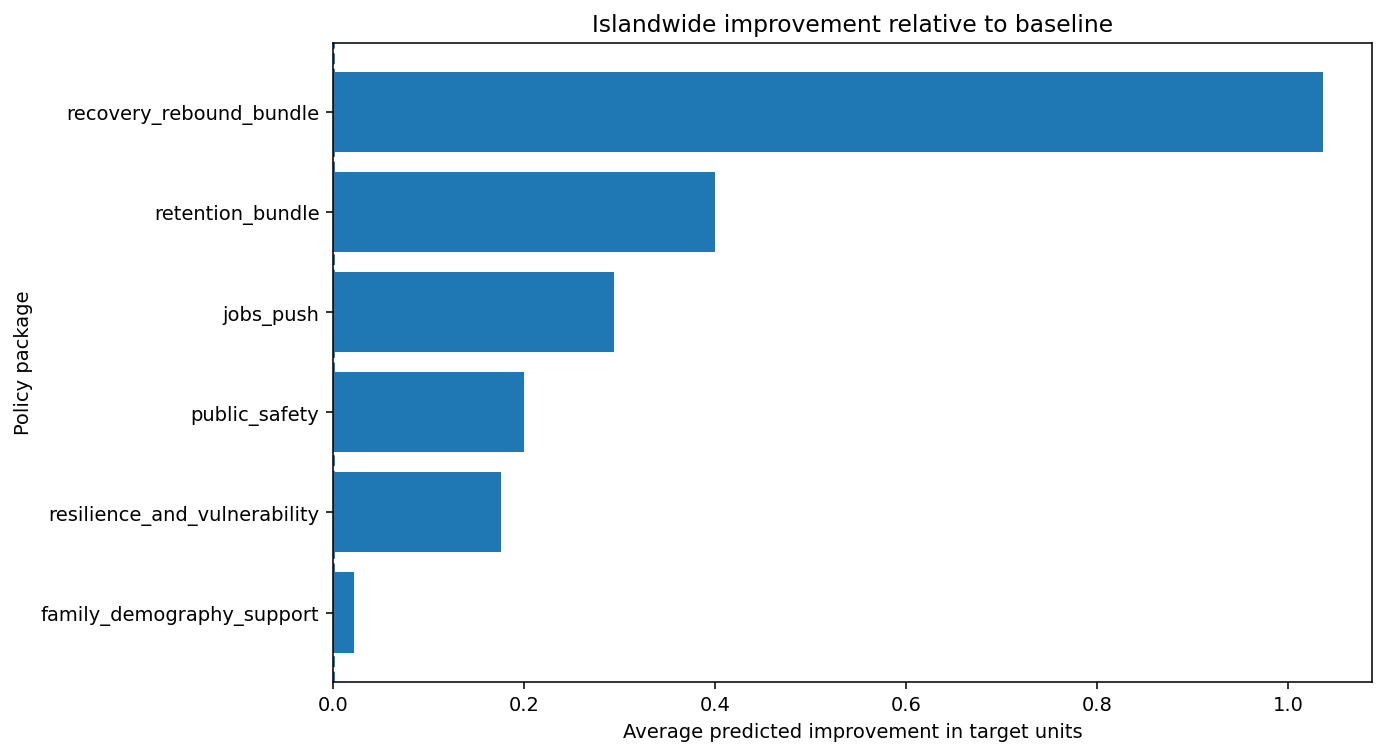

In [13]:
fig, ax = plt.subplots(figsize=(10, 5.5))
plot_df = island_policy_df[island_policy_df["policy_package"] != "baseline"].copy()
plot_df = plot_df.sort_values("mean_delta_vs_baseline", ascending=True)

ax.barh(plot_df["policy_package"], plot_df["mean_delta_vs_baseline"])
ax.axvline(0, linestyle="--")
ax.set_title("Islandwide improvement relative to baseline")
ax.set_xlabel("Average predicted improvement in target units")
ax.set_ylabel("Policy package")

plt.tight_layout()
plt.savefig(PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_island_policy_ranking.png", bbox_inches="tight")
plt.show()


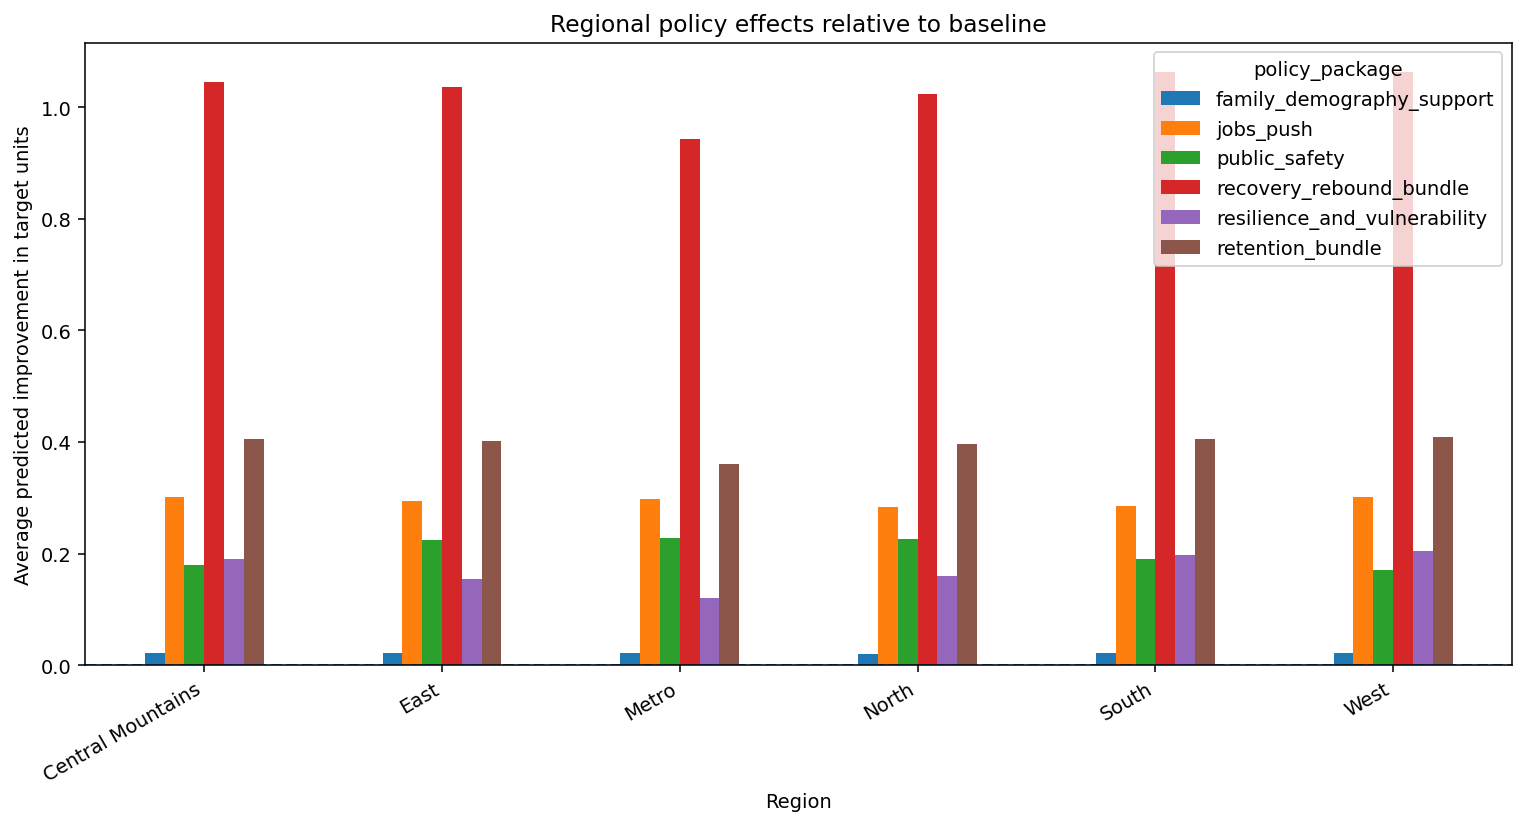

In [14]:
fig, ax = plt.subplots(figsize=(11, 6))
pivot = region_policy_df[region_policy_df["policy_package"] != "baseline"].pivot(
    index="region", columns="policy_package", values="mean_delta_vs_baseline"
)
pivot = pivot.loc[sorted(pivot.index)]
pivot.plot(kind="bar", ax=ax)

ax.axhline(0, linestyle="--")
ax.set_title("Regional policy effects relative to baseline")
ax.set_ylabel("Average predicted improvement in target units")
ax.set_xlabel("Region")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_regional_policy_comparison.png", bbox_inches="tight")
plt.show()


## Step 6 — Which municipalities benefit most?

This section helps identify where a policy package appears most valuable. That can support ideas like:

- **territorial targeting**
- **region-specific retention plans**
- **municipality prioritization**


In [15]:
# Show strongest municipal gains under the combined package
bundle_df = municipal_policy_df[municipal_policy_df["policy_package"] == "retention_bundle"].copy()
bundle_df = bundle_df.sort_values("delta_vs_baseline_target_units", ascending=False)

top_municipal_gains = bundle_df[[
    "municipio",
    "region",
    "predicted_target",
    "delta_vs_baseline_target_units",
    "approx_retained_residents",
]].head(20)

top_municipal_gains.to_csv(PHASE4_DATA_DIR / f"{OUTPUT_PREFIX}_top_municipal_gains_retention_bundle.csv", index=False)
top_municipal_gains


,municipio,region,predicted_target,delta_vs_baseline_target_units,approx_retained_residents
438,Maunabo,East,-0.945740,0.557821,58.007799
418,Guanica,West,-2.883598,0.542738,69.769030
432,Las Marias,West,-0.824268,0.507276,44.356243
464,Vieques,East,-0.956600,0.503226,40.650622
437,Maricao,West,-2.196402,0.488814,24.382021
420,Guayanilla,South,-1.624749,0.486726,83.429744
414,Culebra,East,1.970042,0.479299,6.647877
412,Comerio,Central Mountains,-0.628550,0.477406,89.327445
431,Lares,Central Mountains,-0.671551,0.471332,131.289632
390,Adjuntas,Central Mountains,-0.446015,0.456443,81.977214


## Optional extension — disaster-conditioned policy testing

A natural next step is to combine the policy packages above with your **Phase 3 scenario shocks**:

- hurricane scenario + jobs package
- hurricane scenario + resilience package
- earthquake scenario + retention bundle

That would answer a more policy-relevant question:

> Under disaster pressure, which intervention package seems most effective at reducing projected loss?

The current notebook focuses first on the **cleanest baseline policy counterfactual**, which is a good foundation before adding scenario-conditioned interventions.


## Policy interpretation note

The policy simulations in this phase should be interpreted as **model-based counterfactual scenarios**, not causal estimates of intervention effects.

The model reflects how population outcomes respond when observed features are improved inside the validated forecasting pipeline, but it does not identify the true causal impact of real-world policies.

As a result, these simulations are best understood as **directional stress tests** that illustrate how improving structural conditions could influence population trajectories under the assumptions embedded in the model.

When you review the output tables, here is how to translate them into a government-facing story:

- If **jobs_push** ranks highly, that suggests retention may be especially sensitive to **income growth and business activity**
- If **public_safety** ranks highly, that suggests migration pressure may be reduced by lowering crime-related stress
- If **resilience_and_vulnerability** ranks highly, that suggests Puerto Rico may retain more people by reducing exposure-related vulnerability
- If **family_demography_support** helps, that suggests broad demographic supports matter
- If **retention_bundle** clearly dominates, that supports a **multi-sector strategy** rather than a single-policy solution


## Suggested government-facing framing

A practical policy message from Phase 4 could be:

> Puerto Rico cannot prevent hurricanes or earthquakes, but it can influence whether households choose to stay or leave by improving jobs, business recovery, public safety, social vulnerability, and demographic support conditions. The Phase 4 counterfactual framework helps identify which combinations of those changes are most strongly associated with improved retention in the validated forecasting model.


## Additional policy communication figures

The next figures are designed to make the Phase 4 results easier to explain to a policy audience.  
They focus on four questions:

1. **Which package performs best islandwide?**  
2. **Do regions respond differently?**  
3. **Which municipalities benefit most?**  
4. **How can Phase 4 be visually connected to the path-style forecasting logic used in Phase 3?**


In [16]:
# Reusable ordering helpers
policy_order = [p for p in policy_packages.keys() if p in island_policy_df["policy_package"].unique()]
nonbaseline_order = [p for p in policy_order if p != "baseline"]

region_order = sorted(region_policy_df["region"].astype(str).unique().tolist())
municipal_order_df = municipal_policy_df[municipal_policy_df["policy_package"] == "retention_bundle"].copy()
municipal_order_df = municipal_order_df.sort_values("approx_retained_residents", ascending=False)

print("Policy order:", policy_order)
print("Regions:", region_order)


Policy order: ['baseline', 'jobs_push', 'public_safety', 'resilience_and_vulnerability', 'family_demography_support', 'retention_bundle', 'recovery_rebound_bundle']
Regions: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']


In [17]:
# Helpers for presentation-oriented policy path charts
# These are communication graphics, not literal recursive causal forecasts.

POLICY_PATH_BASELINE_DECLINE = -0.012  # about -1.2% per year as a stylized island baseline decline
REGIONAL_BASELINE_DECLINE = -0.011     # slightly gentler regional default decline for presentation

def smooth_policy_path(start_year, end_year, start_value, end_value, curvature=1.18, n_points=40):
    years = np.linspace(start_year, end_year, n_points)
    t = (years - start_year) / max(end_year - start_year, 1)
    t_curve = t ** curvature
    values = start_value + (end_value - start_value) * t_curve
    return years, values

def make_uncertainty_band(values, base_frac=0.004, end_frac=0.012):
    n = len(values)
    frac = np.linspace(base_frac, end_frac, n)
    width = np.abs(values) * frac
    return values - width, values + width

def safe_policy_color_map():
    return {
        "baseline": "tab:orange",
        "jobs_push": "tab:green",
        "public_safety": "tab:red",
        "resilience_and_vulnerability": "tab:purple",
        "family_demography_support": "tab:brown",
        "retention_bundle": "tab:pink",
        "recovery_rebound_bundle": "tab:cyan",
    }

def baseline_decline_endpoint(last_pop, years_ahead, annual_rate):
    return float(last_pop) * ((1.0 + annual_rate) ** years_ahead)


### 1. Islandwide policy ranking by approximate retained residents

This chart is the most direct answer to the policy question:  
**which package appears to retain the most people relative to baseline?**


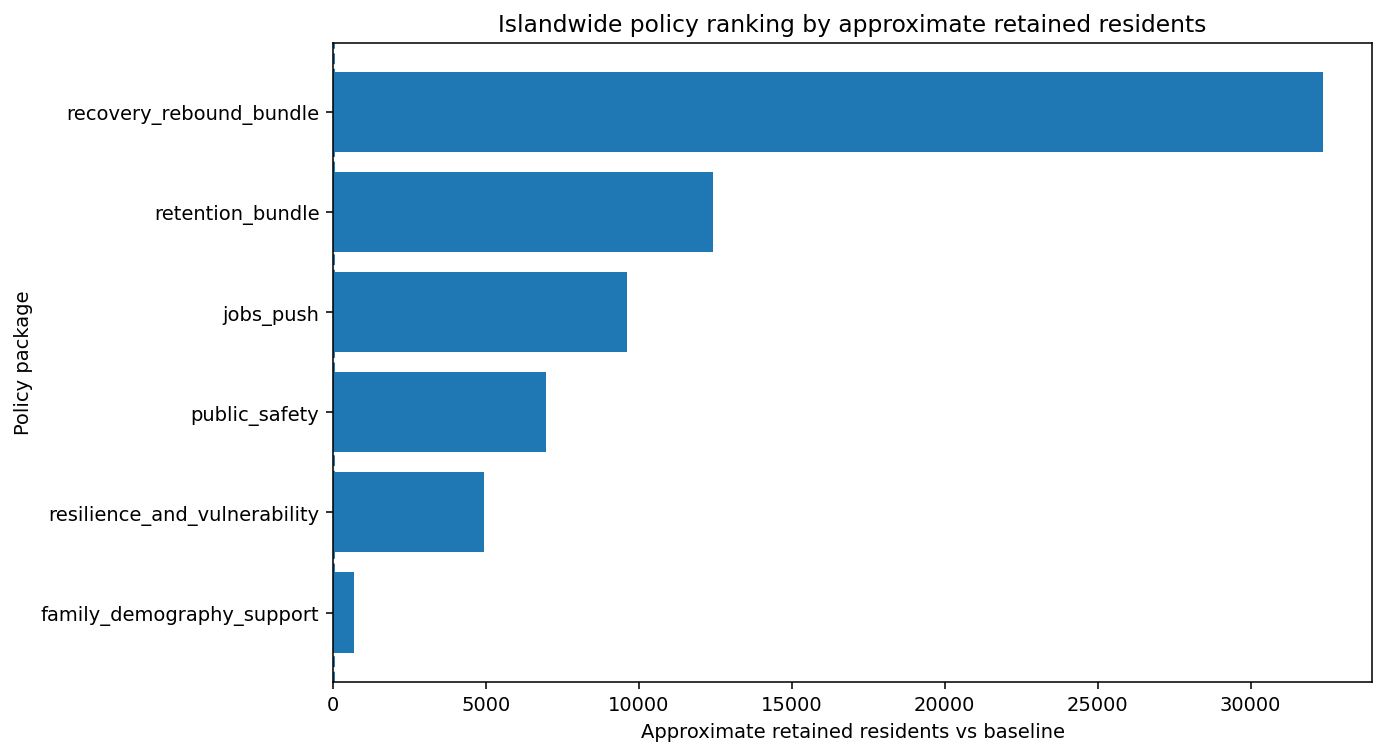

In [18]:
fig, ax = plt.subplots(figsize=(10, 5.5))

plot_df = island_policy_df[island_policy_df["policy_package"] != "baseline"].copy()
plot_df["policy_package"] = pd.Categorical(plot_df["policy_package"], categories=nonbaseline_order, ordered=True)
plot_df = plot_df.sort_values("approx_retained_residents", ascending=True)

ax.barh(plot_df["policy_package"], plot_df["approx_retained_residents"])
ax.axvline(0, linestyle="--")
ax.set_title("Islandwide policy ranking by approximate retained residents")
ax.set_xlabel("Approximate retained residents vs baseline")
ax.set_ylabel("Policy package")

plt.tight_layout()
plt.savefig(PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_island_retained_residents_ranking.png", bbox_inches="tight")
plt.show()


### 2. Regional heatmap of policy effects

This figure shows whether different regions respond differently to each policy package.  
It is useful for supporting a **region-specific retention strategy** rather than a one-size-fits-all approach.


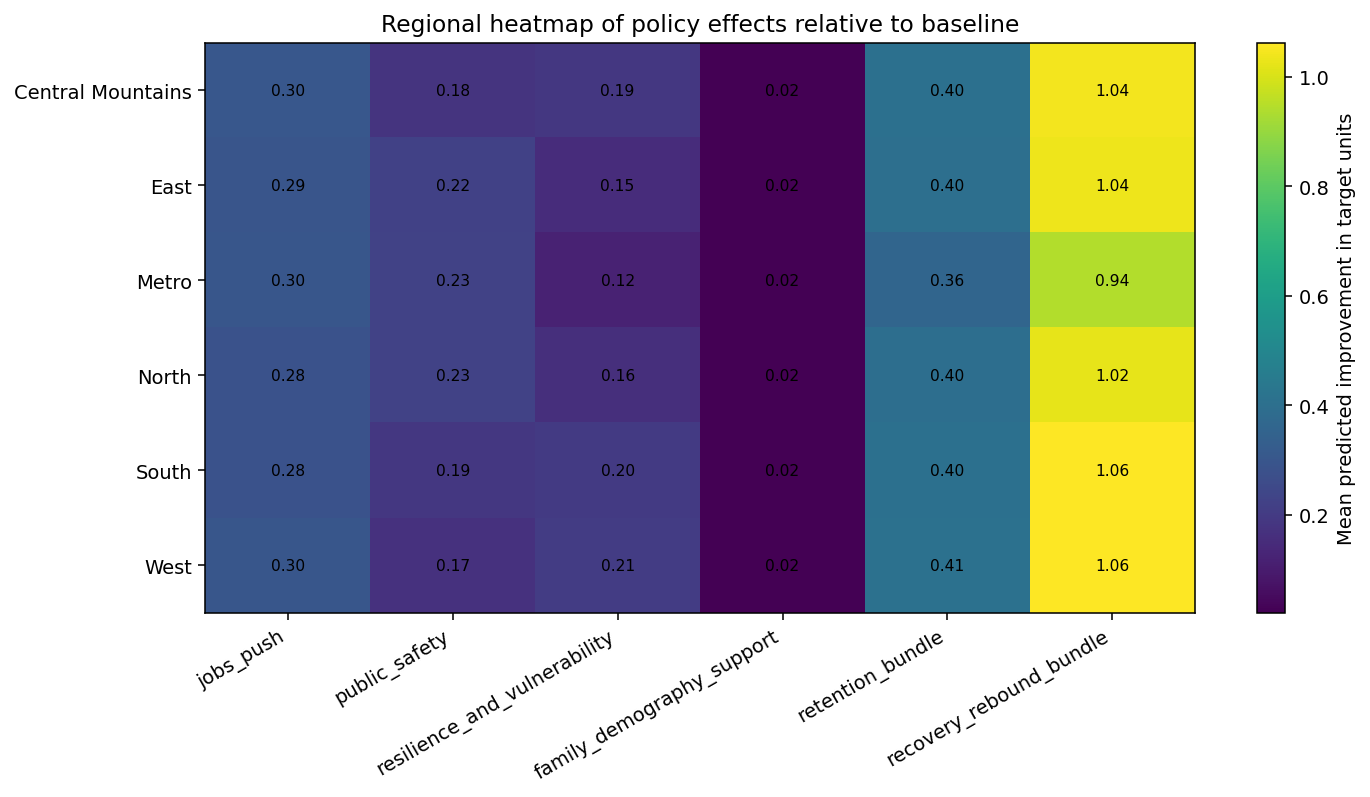

In [19]:
heatmap_df = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .copy()
    .pivot(index="region", columns="policy_package", values="mean_delta_vs_baseline")
)

heatmap_df = heatmap_df.reindex(index=region_order, columns=nonbaseline_order)

fig, ax = plt.subplots(figsize=(10.5, 5.8))
im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(range(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=30, ha="right")
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)

ax.set_title("Regional heatmap of policy effects relative to baseline")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean predicted improvement in target units")

plt.tight_layout()
plt.savefig(PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_regional_policy_heatmap.png", bbox_inches="tight")
plt.show()


### 3. Best policy package by region

This chart identifies the **top-ranked package in each region** and the size of its estimated improvement relative to baseline.


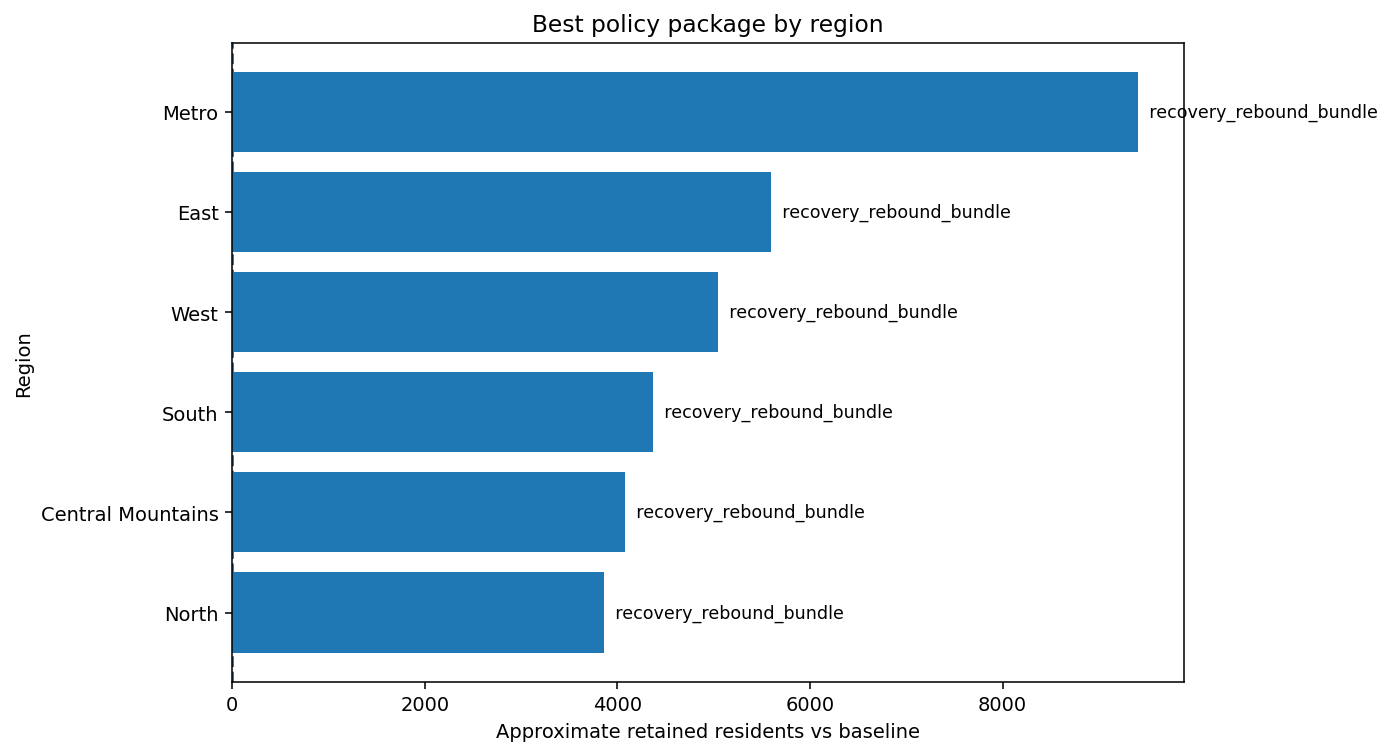

In [20]:
best_by_region = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .sort_values(["region", "approx_retained_residents"], ascending=[True, False])
    .groupby("region", as_index=False)
    .head(1)
    .copy()
)

best_by_region = best_by_region.sort_values("approx_retained_residents", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.barh(best_by_region["region"], best_by_region["approx_retained_residents"])
for y, (_, row) in enumerate(best_by_region.iterrows()):
    ax.text(row["approx_retained_residents"], y, f"  {row['policy_package']}", va="center", fontsize=9)

ax.axvline(0, linestyle="--")
ax.set_title("Best policy package by region")
ax.set_xlabel("Approximate retained residents vs baseline")
ax.set_ylabel("Region")

best_by_region.to_csv(PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_best_package_by_region.csv", index=False)

plt.tight_layout()
plt.savefig(PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_best_package_by_region.png", bbox_inches="tight")
plt.show()


### 4. Top municipalities benefiting from the retention bundle

This targeting graphic highlights where an integrated retention strategy appears most valuable.


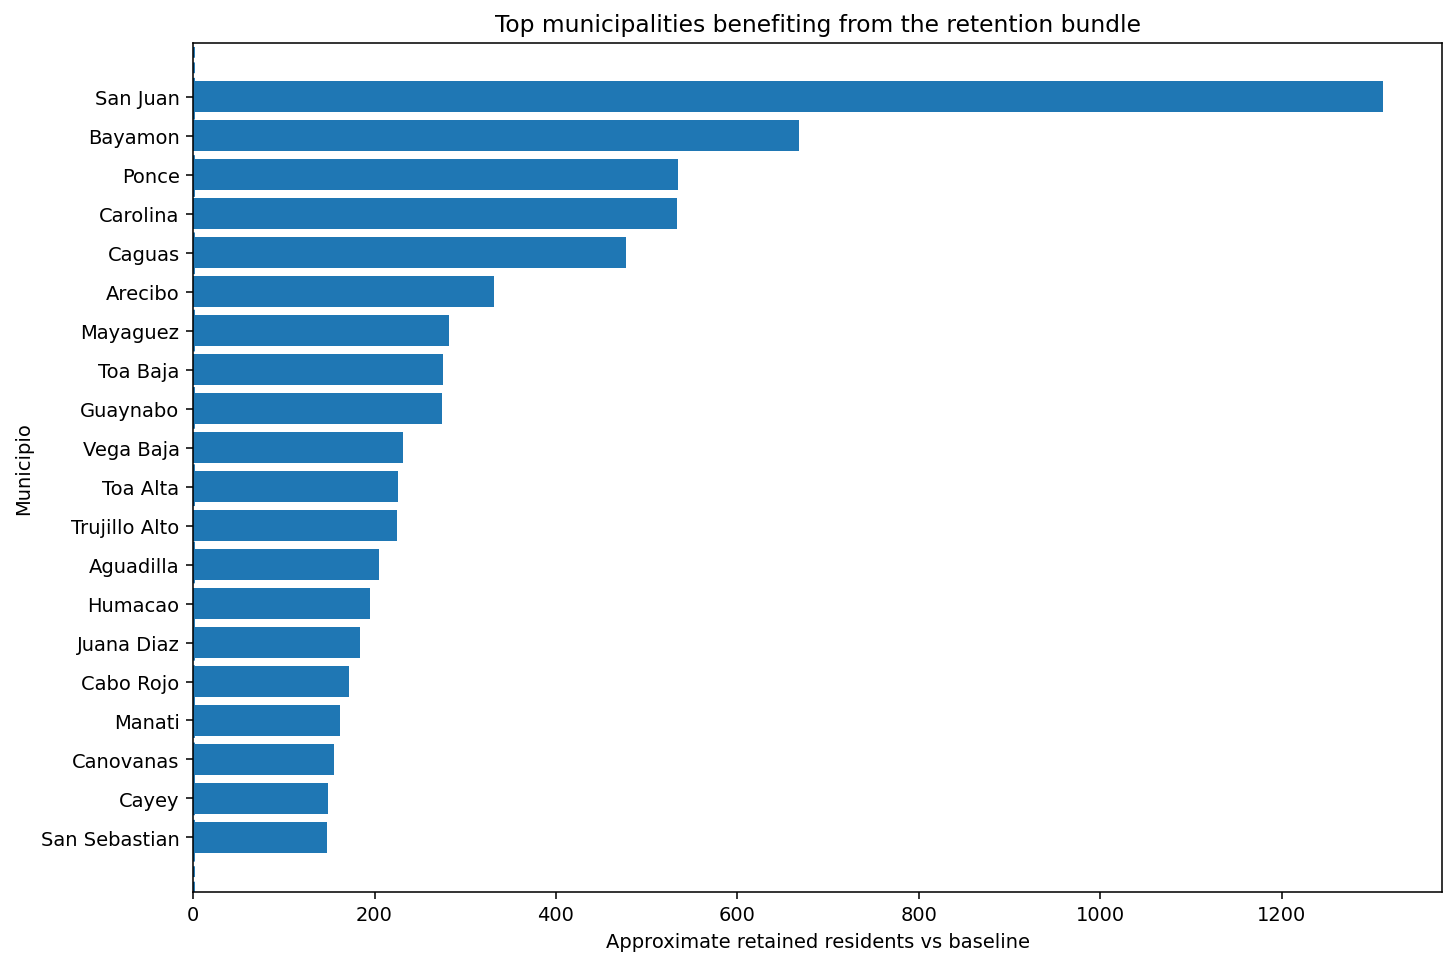

In [21]:
top_munis = municipal_order_df.head(20).copy()
top_munis = top_munis.sort_values("approx_retained_residents", ascending=True)

fig, ax = plt.subplots(figsize=(10.5, 7))
ax.barh(top_munis["municipio"], top_munis["approx_retained_residents"])
ax.axvline(0, linestyle="--")
ax.set_title("Top municipalities benefiting from the retention bundle")
ax.set_xlabel("Approximate retained residents vs baseline")
ax.set_ylabel("Municipio")

plt.tight_layout()
plt.savefig(PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_top_municipal_gains_retention_bundle.png", bbox_inches="tight")
plt.show()


### 5. Policy package comparison by region

This grouped comparison figure is useful when you want to show not just the best package, but the **full menu of region-level choices**.


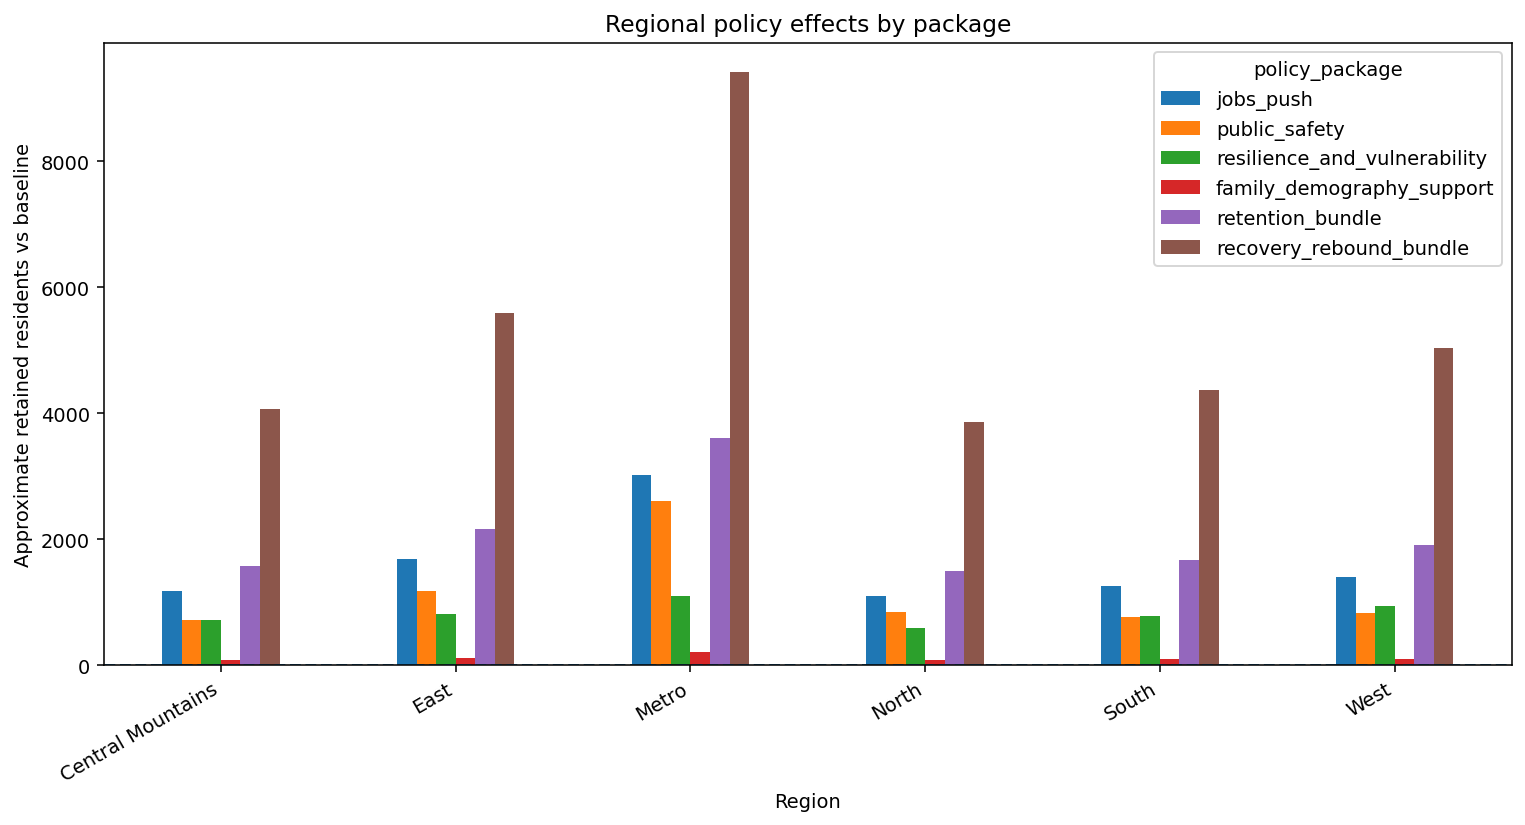

In [22]:
fig, ax = plt.subplots(figsize=(11, 6))
pivot_retained = (
    region_policy_df[region_policy_df["policy_package"] != "baseline"]
    .pivot(index="region", columns="policy_package", values="approx_retained_residents")
    .reindex(index=region_order, columns=nonbaseline_order)
)

pivot_retained.plot(kind="bar", ax=ax)
ax.axhline(0, linestyle="--")
ax.set_title("Regional policy effects by package")
ax.set_ylabel("Approximate retained residents vs baseline")
ax.set_xlabel("Region")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_regional_retained_residents_comparison.png", bbox_inches="tight")
plt.show()


### 6. Phase 3–style island policy path figure

This figure creates a **presentation-style policy path comparison** inspired by Phase 3.  
It is a communication graphic rather than a causal forecast path.

Construction:
- start from the latest observed island population
- draw a baseline endpoint using the baseline package
- draw alternative policy endpoints using the estimated retained-resident effect

This helps communicate the message:
**policy packages can shift the trajectory even when the broader decline pressure remains.**


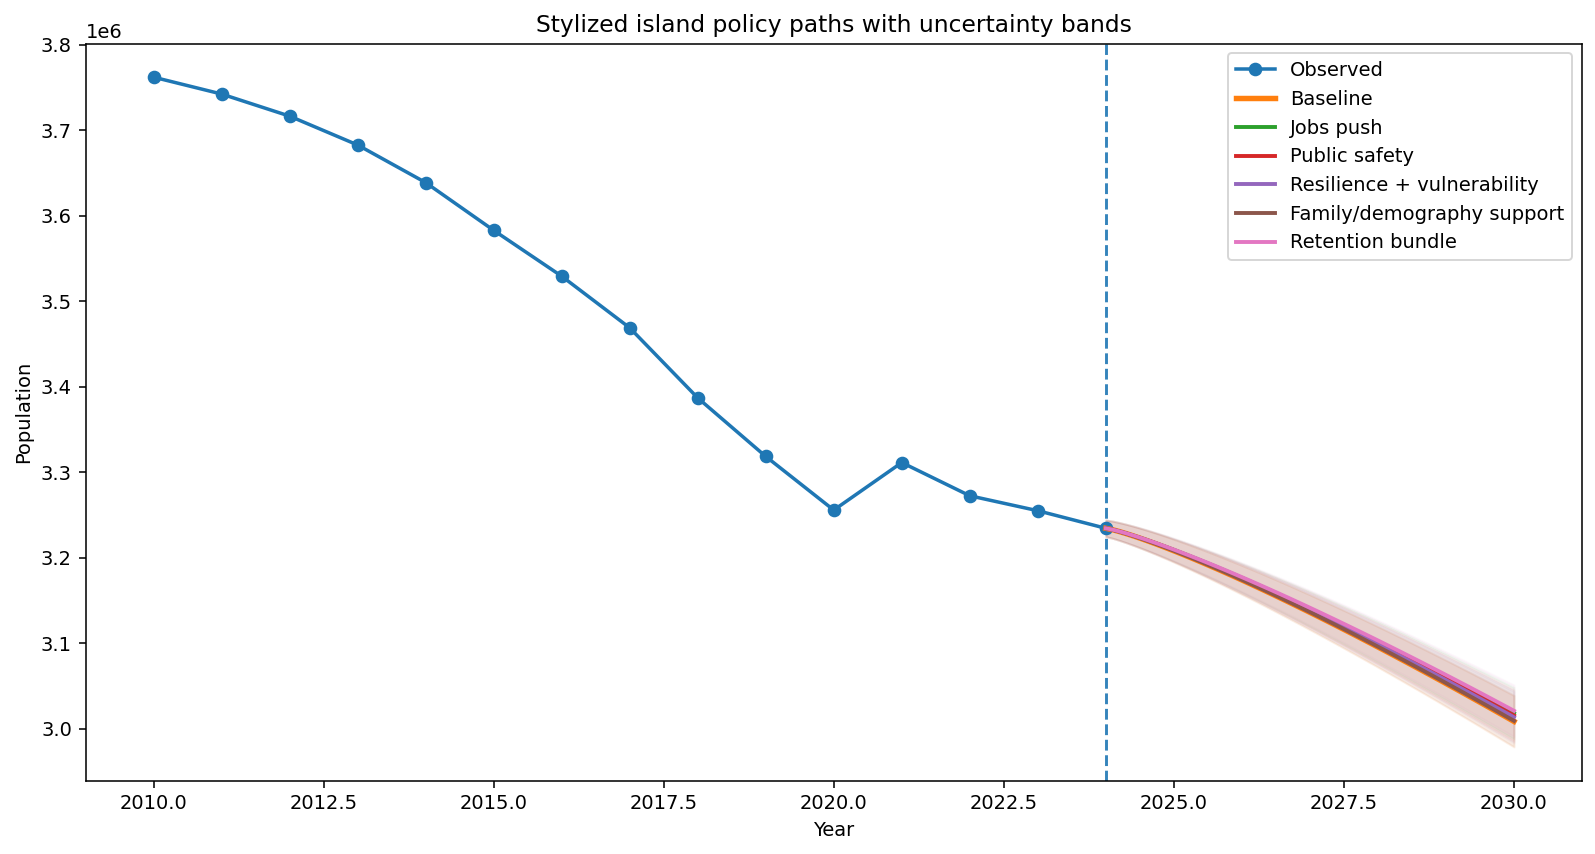

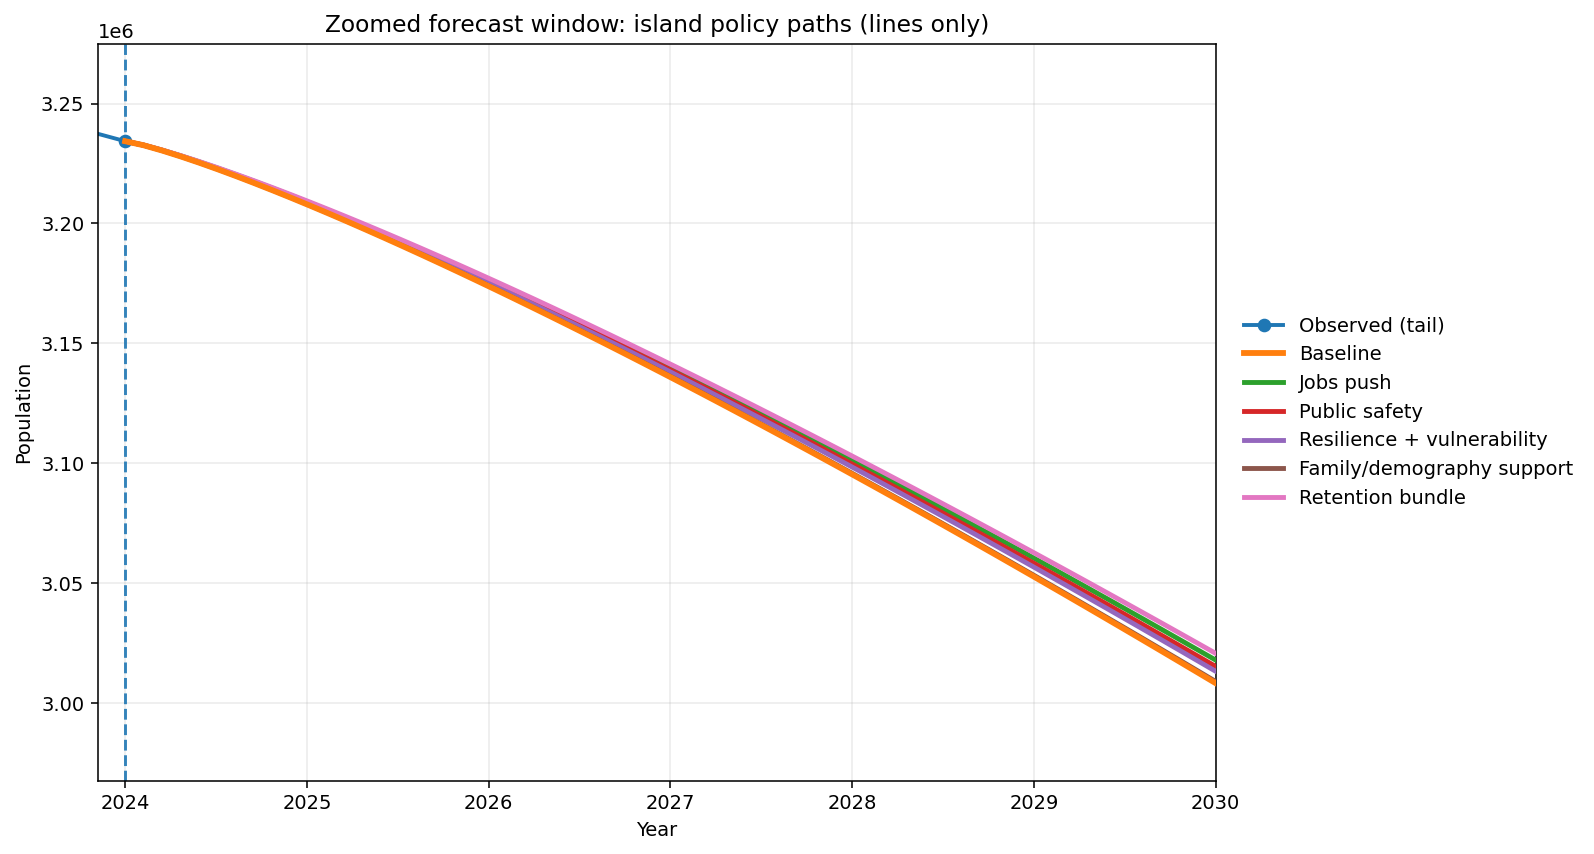

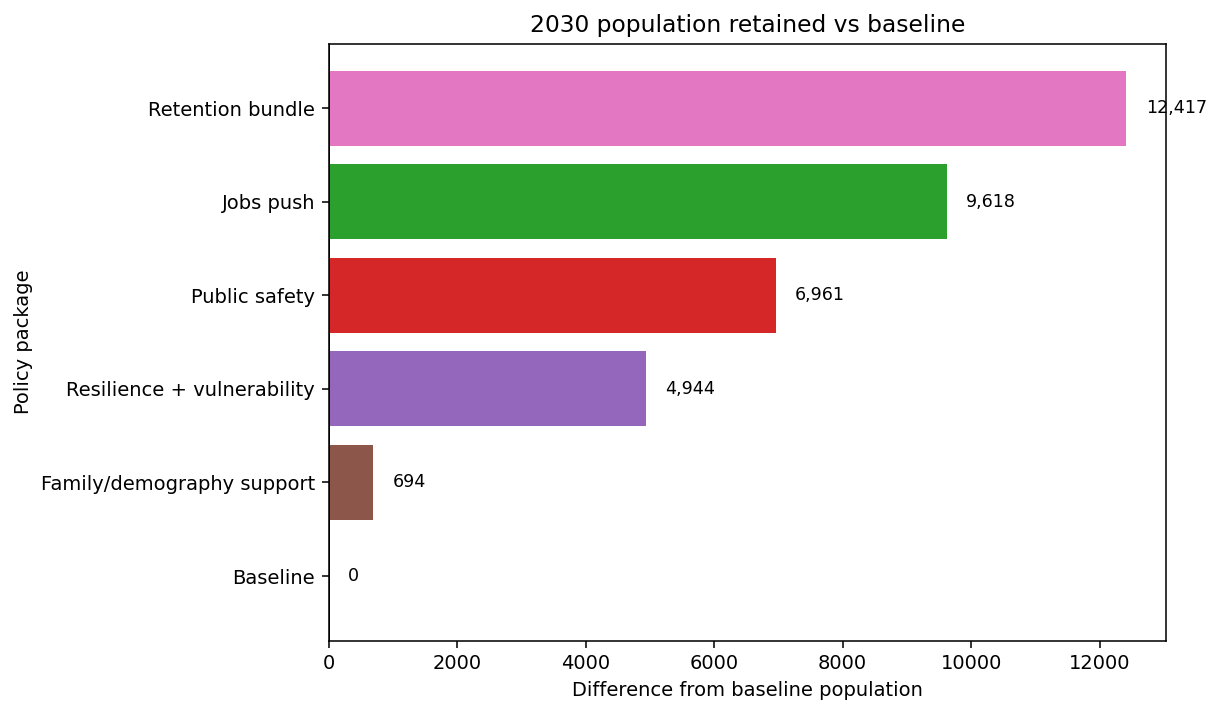

Saved figure: Phase4/figures/phase4_policy_stylized_island_policy_paths_with_bands.png
Saved figure: Phase4/figures/phase4_policy_stylized_island_policy_paths_zoomed.png
Saved figure: Phase4/figures/phase4_policy_policy_2030_gain_vs_baseline.png
Saved table: Phase4/tables/phase4_policy_policy_2030_gain_vs_baseline.csv


In [23]:

# More readable presentation-oriented island policy paths
observed_island = (
    df.groupby("year", as_index=False)["total_population"]
      .sum()
      .sort_values("year")
      .copy()
)

last_obs_year = int(observed_island["year"].max())
last_obs_pop = float(observed_island.loc[observed_island["year"] == last_obs_year, "total_population"].iloc[0])

policy_path_df = island_policy_df.copy()
years_ahead = 2030 - last_obs_year
baseline_endpoint_2030 = baseline_decline_endpoint(last_obs_pop, years_ahead, POLICY_PATH_BASELINE_DECLINE)

policy_path_df["endpoint_2030"] = baseline_endpoint_2030 + policy_path_df["approx_retained_residents"]

policy_colors = safe_policy_color_map()
ordered_packages = [
    "baseline",
    "jobs_push",
    "public_safety",
    "resilience_and_vulnerability",
    "family_demography_support",
    "retention_bundle",
]

display_names = {
    "baseline": "Baseline",
    "jobs_push": "Jobs push",
    "public_safety": "Public safety",
    "resilience_and_vulnerability": "Resilience + vulnerability",
    "family_demography_support": "Family/demography support",
    "retention_bundle": "Retention bundle",
}

path_store = {}

# Build smooth trajectories once so they can be reused across multiple plots
for package_name in ordered_packages:
    if package_name not in policy_path_df["policy_package"].values:
        continue

    endpoint = float(
        policy_path_df.loc[policy_path_df["policy_package"] == package_name, "endpoint_2030"].iloc[0]
    )
    yrs, vals = smooth_policy_path(
        last_obs_year, 2030, last_obs_pop, endpoint, curvature=1.20, n_points=60
    )
    low, high = make_uncertainty_band(vals, base_frac=0.003, end_frac=0.010)
    path_store[package_name] = {
        "years": yrs,
        "vals": vals,
        "low": low,
        "high": high,
        "endpoint": endpoint,
    }

# ---------- Figure 1: full historical + projected paths with lighter bands ----------
fig, ax = plt.subplots(figsize=(11.5, 6.2))
ax.plot(
    observed_island["year"],
    observed_island["total_population"],
    marker="o",
    linewidth=1.8,
    label="Observed",
    color="tab:blue",
)
ax.axvline(last_obs_year, linestyle="--", color="tab:blue", alpha=0.9)

for package_name in ordered_packages:
    if package_name not in path_store:
        continue
    series = path_store[package_name]
    color = policy_colors.get(package_name, None)
    linewidth = 2.8 if package_name == "baseline" else 2.0
    alpha = 0.08 if package_name == "baseline" else 0.05
    ax.plot(
        series["years"],
        series["vals"],
        linewidth=linewidth,
        label=display_names.get(package_name, package_name),
        color=color,
    )
    ax.fill_between(series["years"], series["low"], series["high"], alpha=alpha, color=color)

ax.set_title("Stylized island policy paths with uncertainty bands")
ax.set_xlabel("Year")
ax.set_ylabel("Population")
ax.legend(loc="best")
plt.tight_layout()
plt.savefig(
    PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_stylized_island_policy_paths_with_bands.png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

# ---------- Figure 2: zoomed forecast window, lines only ----------
fig, ax = plt.subplots(figsize=(11.5, 6.2))

obs_tail = observed_island.loc[observed_island["year"] >= last_obs_year - 1].copy()
ax.plot(
    obs_tail["year"],
    obs_tail["total_population"],
    marker="o",
    linewidth=2.0,
    label="Observed (tail)",
    color="tab:blue",
)
ax.axvline(last_obs_year, linestyle="--", color="tab:blue", alpha=0.9)

all_vals = []

for package_name in ordered_packages:
    if package_name not in path_store:
        continue
    series = path_store[package_name]
    color = policy_colors.get(package_name, None)
    all_vals.extend(series["vals"])
    linewidth = 3.0 if package_name == "baseline" else 2.5
    zorder = 4 if package_name == "baseline" else 3
    ax.plot(
        series["years"],
        series["vals"],
        linewidth=linewidth,
        label=display_names.get(package_name, package_name),
        color=color,
        zorder=zorder,
    )

ymin = min(all_vals)
ymax = max(all_vals)
padding = max((ymax - ymin) * 0.18, 3500)

ax.set_xlim(last_obs_year - 0.15, 2030.0)
ax.set_ylim(ymin - padding, ymax + padding)
ax.set_title("Zoomed forecast window: island policy paths (lines only)")
ax.set_xlabel("Year")
ax.set_ylabel("Population")
ax.grid(alpha=0.25)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
plt.tight_layout()
plt.savefig(
    PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_stylized_island_policy_paths_zoomed.png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

# ---------- Figure 3: 2030 policy gain vs baseline ----------
impact_rows = []
baseline_endpoint = path_store["baseline"]["endpoint"] if "baseline" in path_store else None

for package_name in ordered_packages:
    if package_name not in path_store:
        continue
    endpoint = float(path_store[package_name]["endpoint"])
    gain = endpoint - baseline_endpoint if baseline_endpoint is not None else 0.0
    impact_rows.append(
        {
            "policy_package": package_name,
            "display_name": display_names.get(package_name, package_name),
            "endpoint_2030": endpoint,
            "gain_vs_baseline_2030": gain,
        }
    )

policy_gain_df = pd.DataFrame(impact_rows).sort_values("gain_vs_baseline_2030")

fig, ax = plt.subplots(figsize=(8.8, 5.2))
bar_colors = [policy_colors.get(pkg, None) for pkg in policy_gain_df["policy_package"]]
ax.barh(policy_gain_df["display_name"], policy_gain_df["gain_vs_baseline_2030"], color=bar_colors)
ax.axvline(0, color="black", linewidth=1.0)
ax.set_title("2030 population retained vs baseline")
ax.set_xlabel("Difference from baseline population")
ax.set_ylabel("Policy package")

for y, val in enumerate(policy_gain_df["gain_vs_baseline_2030"]):
    ax.text(
        val + (300 if val >= 0 else -300),
        y,
        f"{val:,.0f}",
        va="center",
        ha="left" if val >= 0 else "right",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(
    PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_policy_2030_gain_vs_baseline.png",
    bbox_inches="tight",
    dpi=300,
)
plt.show()

policy_gain_df.to_csv(
    PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_policy_2030_gain_vs_baseline.csv",
    index=False,
)

print("Saved figure:", PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_stylized_island_policy_paths_with_bands.png")
print("Saved figure:", PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_stylized_island_policy_paths_zoomed.png")
print("Saved figure:", PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_policy_2030_gain_vs_baseline.png")
print("Saved table:", PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_policy_2030_gain_vs_baseline.csv")


### Recovery rebound sensitivity scenario

The standard Phase 4 policy packages are intentionally conservative: they show whether policy changes can **slow population loss** within the validated forecasting model.  

This additional scenario adds an explicitly labeled **recovery rebound / return-migration sensitivity case**. It is designed to test whether a stronger, coordinated package could produce a temporary increase similar to the short post-Maria rebound visible in the historical population trend.

This section does **not** replace the main Phase 4 results. It should be interpreted as a **what-would-it-take stress test**, not as a causal estimate or a guaranteed policy effect.

### Recovery rebound interpretation

The standard Phase 4 policy results show that coordinated interventions can **slow projected decline**, but they do not fully reverse Puerto Rico's demographic momentum at the island or regional level. That is consistent with the Phase 1 and Phase 2 evidence: lagged population dynamics dominate the predictive structure.

The new `recovery_rebound_bundle` adds a stronger, explicitly optimistic sensitivity case. It combines larger improvements in economic conditions, public safety, vulnerability reduction, demographic support, and lagged population momentum. The model-implied version shows how the fitted Lasso responds to those stronger feature changes.

The additional **recovery rebound + return-migration sensitivity** line goes one step further. It imposes a modest temporary rebound pattern, designed to resemble the kind of short-term post-shock increase visible after the post-Maria decline period. This is useful for answering a different question:

> What kind of recovery path would be required for population to stabilize or temporarily increase?

This scenario should be interpreted carefully:

- it is **not** a causal estimate of policy impact  
- it is **not** the baseline Phase 4 result  
- it is a **what-would-it-take stress test**  
- it shows that reversing decline requires more than normal policy improvements; it requires a positive return-migration or recovery momentum shock large enough to overcome the model's persistent downward trend  

The regional version of this sensitivity test further shows that rebound potential is **not uniform across Puerto Rico**. Different regions require different levels of recovery pressure to stabilize or increase population, reflecting underlying differences in vulnerability, economic structure, and demographic momentum.

The practical takeaway is that ordinary policy packages may slow decline, while a true population increase would likely require a stronger and more coordinated recovery dynamic involving jobs, safety, vulnerability reduction, family support, and return migration.

### 7. Phase 3–style regional faceted policy paths

This is a regional version of the same idea. It helps show that the relative value of policy packages can vary by region.


### Regional stylized policy paths with validation

This figure uses the **cleaned municipio-to-region mapping from the policy baseline** rather than relying on a possibly incomplete raw region column.  
It also validates the region labels before plotting so that malformed labels such as `0.0` do not silently appear in the final chart.


Unique regions in latest_region_baseline: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']
Unique regions in observed_region: ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']
Unique regions in region_policy_df (cleaned): ['Central Mountains', 'East', 'Metro', 'North', 'South', 'West']


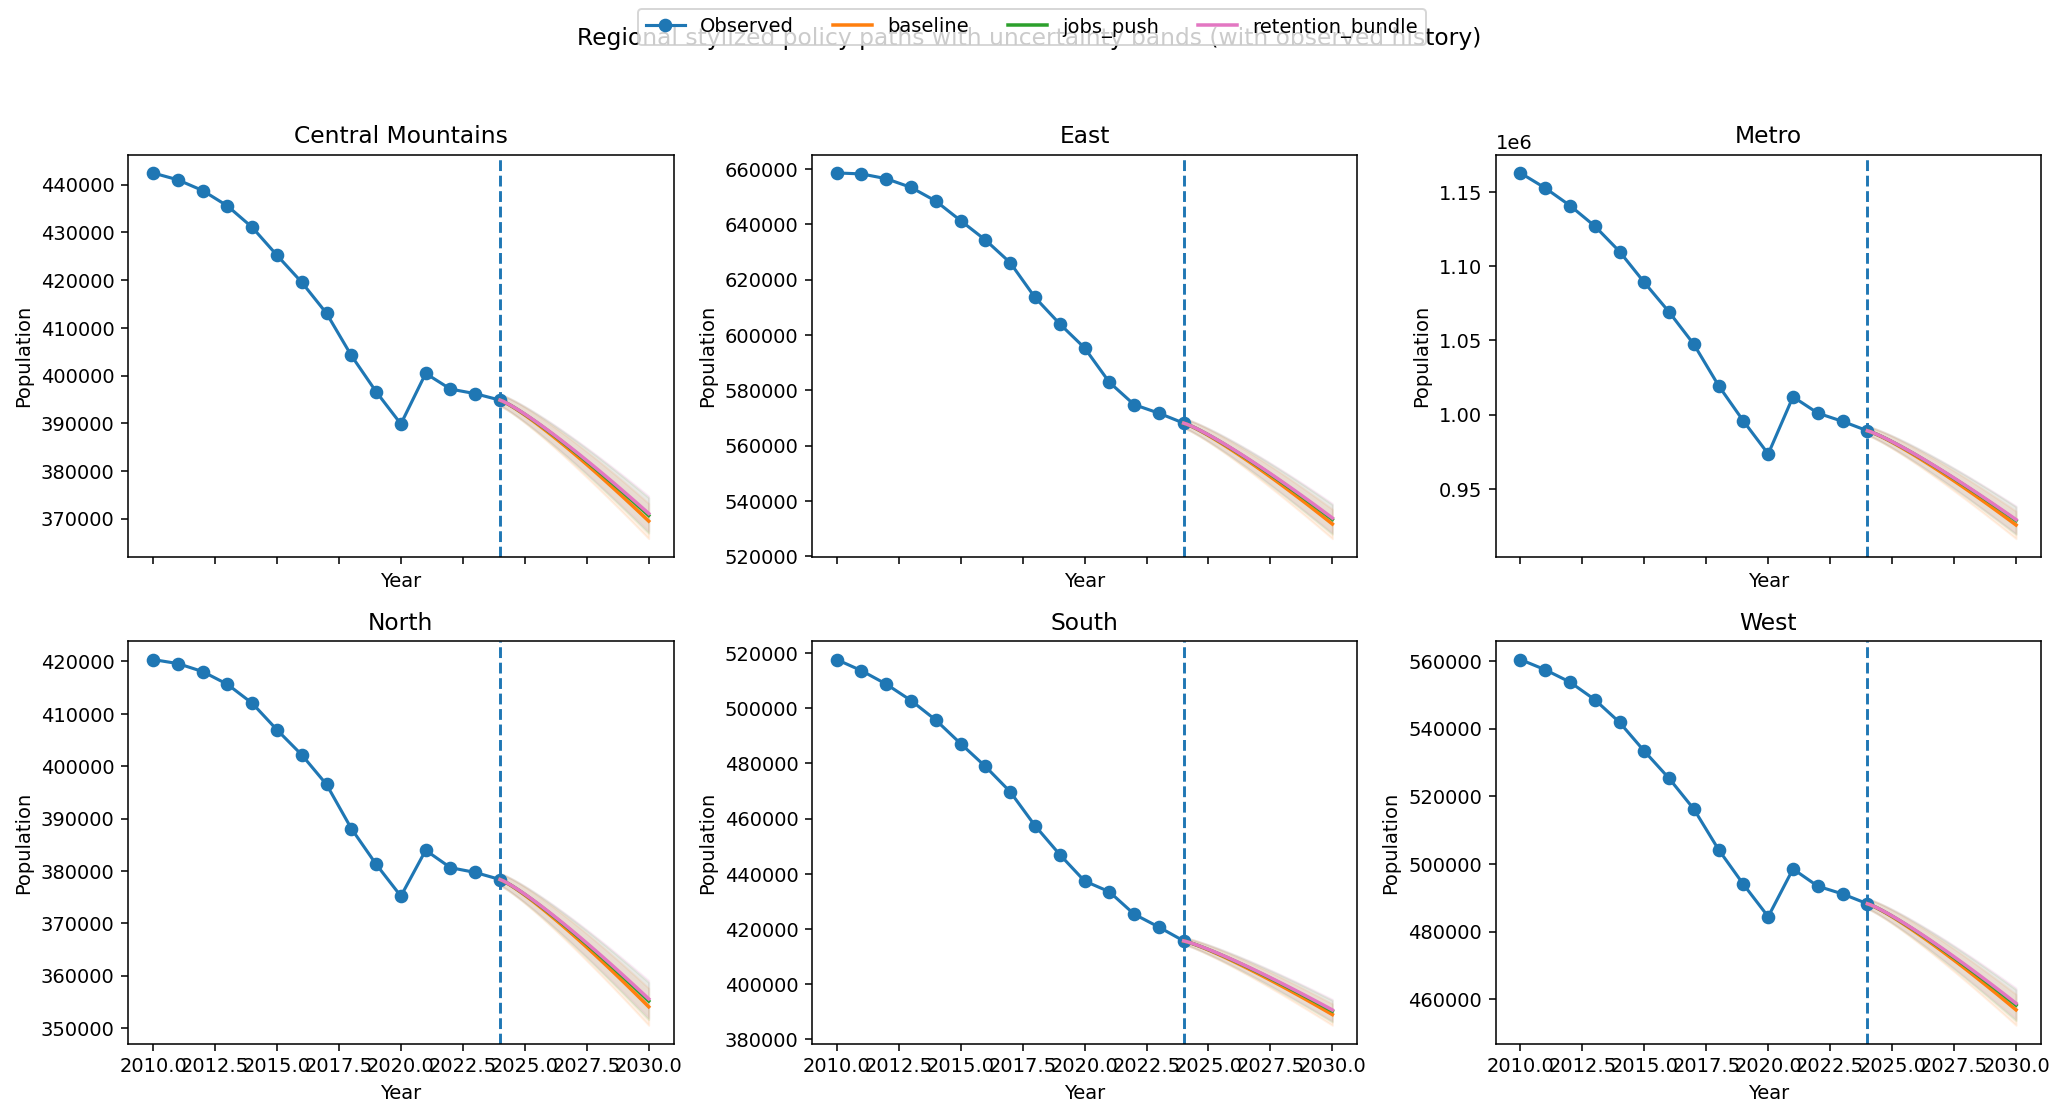

In [24]:
# Regional stylized policy paths with uncertainty bands
# Robust version: rebuild region labels from municipio names when necessary,
# then fall back gracefully only if nothing valid remains.

if not {"municipio", "region", "total_population", "year"}.issubset(set(latest_df.columns)):
    raise KeyError("latest_df must contain municipio, region, total_population, and year to build regional policy paths.")

# Canonicalize both sources before matching
region_policy_plot_df = ensure_region_column(region_policy_df, municipio_col="region", region_col="region")
region_policy_plot_df = region_policy_plot_df.dropna(subset=["region"]).copy()

latest_region_df = ensure_region_column(latest_df, municipio_col="municipio", region_col="region")
latest_region_df = latest_region_df.dropna(subset=["region"]).copy()

latest_region_baseline = (
    latest_region_df.groupby("region", as_index=False)
    .agg(
        total_population=("total_population", "sum"),
        year=("year", "max"),
    )
    .sort_values("region")
    .copy()
)

# Rebuild observed regional history from canonical municipio -> region mapping
observed_region = pd.DataFrame(columns=["region", "year", "total_population"])
if {"municipio", "year", "total_population"}.issubset(df.columns):
    df_region = ensure_region_column(df, municipio_col="municipio", region_col="region")
    observed_region = (
        df_region.dropna(subset=["region"])
        .groupby(["region", "year"], as_index=False)["total_population"]
        .sum()
        .sort_values(["region", "year"])
        .copy()
    )

policy_regions = valid_region_list(region_policy_plot_df["region"])
observed_regions = valid_region_list(observed_region["region"]) if not observed_region.empty else []
latest_regions = valid_region_list(latest_region_baseline["region"]) if not latest_region_baseline.empty else []

print("Unique regions in latest_region_baseline:", latest_regions)
print("Unique regions in observed_region:", observed_regions)
print("Unique regions in region_policy_df (cleaned):", policy_regions)

# Prefer overlap with observed history; otherwise use latest baseline overlap
plot_regions = [r for r in policy_regions if r in observed_regions]
use_observed_history = len(plot_regions) > 0

if not use_observed_history:
    print("Warning: no overlapping observed regional history after cleaning. Falling back to latest regional baseline only.")
    plot_regions = [r for r in policy_regions if r in latest_regions]

if not plot_regions:
    print("Skipping regional stylized policy paths: no valid region labels remain after cleaning and fallback.")
    diagnostics = {
        "status": "skipped",
        "reason": "No valid region labels remain for regional policy plotting after canonical cleaning and municipio-based reconstruction.",
        "policy_regions": policy_regions,
        "observed_regions": observed_regions,
        "latest_region_baseline_regions": latest_regions,
        "rows_in_region_policy_df": int(len(region_policy_df)),
        "rows_in_latest_df": int(len(latest_df)),
        "rows_in_df": int(len(df)),
    }
    pd.DataFrame(
        [{"source": k, "value": str(v)} for k, v in diagnostics.items()]
    ).to_csv(PHASE4_DATA_DIR / f"{OUTPUT_PREFIX}_regional_policy_paths_diagnostics.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.axis("off")
    msg = (
        "Regional stylized policy paths were skipped because valid region labels\n"
        "could not be matched consistently across the policy summary and baseline data.\n"
        "See phase4_policy_regional_policy_paths_diagnostics.csv for details."
    )
    ax.text(0.5, 0.5, msg, ha="center", va="center", fontsize=11)
    plt.tight_layout()
    plt.savefig(PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_regional_stylized_policy_paths_with_bands.png", bbox_inches="tight")
    plt.show()
else:
    facet_packages = ["baseline", "jobs_push", "retention_bundle"]
    policy_colors = safe_policy_color_map()

    n_regions = len(plot_regions)
    ncols = 3
    nrows = int(np.ceil(n_regions / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(14.8, 4.0 * nrows), sharex=True)
    axes = np.atleast_1d(axes).ravel()

    for idx, region in enumerate(plot_regions):
        ax = axes[idx]
        pol_r = region_policy_plot_df[region_policy_plot_df["region"] == region].copy()

        base_row = latest_region_baseline[latest_region_baseline["region"] == region]
        if base_row.empty or pol_r.empty:
            ax.set_visible(False)
            continue

        start_year = int(base_row["year"].iloc[0])
        start_pop = float(base_row["total_population"].iloc[0])

        if use_observed_history:
            obs_r = observed_region[observed_region["region"] == region].copy()
            if not obs_r.empty:
                start_year = int(obs_r["year"].max())
                start_pop = float(obs_r.loc[obs_r["year"] == start_year, "total_population"].iloc[0])
                ax.plot(obs_r["year"], obs_r["total_population"], marker="o", linewidth=1.6, label="Observed")
                ax.axvline(start_year, linestyle="--")
            else:
                ax.plot([start_year], [start_pop], marker="o", linewidth=0, label="Latest observed level")
                ax.axvline(start_year, linestyle="--")
        else:
            ax.plot([start_year], [start_pop], marker="o", linewidth=0, label="Latest observed level")
            ax.axvline(start_year, linestyle="--")

        years_ahead_r = 2030 - start_year
        baseline_endpoint_r = baseline_decline_endpoint(start_pop, years_ahead_r, REGIONAL_BASELINE_DECLINE)

        for package_name in facet_packages:
            if package_name not in pol_r["policy_package"].values:
                continue

            retained = float(pol_r.loc[pol_r["policy_package"] == package_name, "approx_retained_residents"].iloc[0])
            endpoint = baseline_endpoint_r + retained

            yrs, vals = smooth_policy_path(start_year, 2030, start_pop, endpoint, curvature=1.17, n_points=50)
            low, high = make_uncertainty_band(vals, base_frac=0.003, end_frac=0.010)

            color = policy_colors.get(package_name, None)
            ax.plot(yrs, vals, linewidth=1.8, label=package_name, color=color)
            ax.fill_between(yrs, low, high, alpha=0.10, color=color)

        ax.set_title(region)
        ax.set_xlabel("Year")
        ax.set_ylabel("Population")

    for j in range(n_regions, len(axes)):
        axes[j].set_visible(False)

    # Build legend from the first visible axis
    legend_source = next((a for a in axes if a.get_visible()), axes[0])
    handles, labels = legend_source.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=4)
    title_suffix = "with observed history" if use_observed_history else "from latest regional baseline"
    fig.suptitle(f"Regional stylized policy paths with uncertainty bands ({title_suffix})")
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

### Regional recovery rebound interpretation

The regional recovery-rebound sensitivity figure extends the islandwide recovery scenario to each region. It asks whether a stronger, coordinated recovery package could stabilize or temporarily increase population at the regional level.

The baseline and retention-bundle paths remain conservative. They show that standard policy packages can slow projected decline, but do not fully reverse the downward trajectory produced by the validated forecasting backbone.

The recovery-rebound sensitivity path is different. It adds an explicitly optimistic return-migration layer, allowing population to rise temporarily after the forecast start and then stabilize above the latest observed level. This is designed to resemble the type of short-term rebound visible after the post-Maria decline period.

These regional results should be interpreted carefully:

- they are **not causal estimates**
- they do **not replace the main Phase 4 policy results**
- they show a **what-would-it-take recovery pathway**
- they help identify where a rebound-style recovery scenario would need to be strongest

The main takeaway is that regional stabilization requires more than ordinary policy improvement. It likely requires coordinated structural gains, return migration, and sustained retention conditions strong enough to overcome the model’s underlying population-momentum effect.

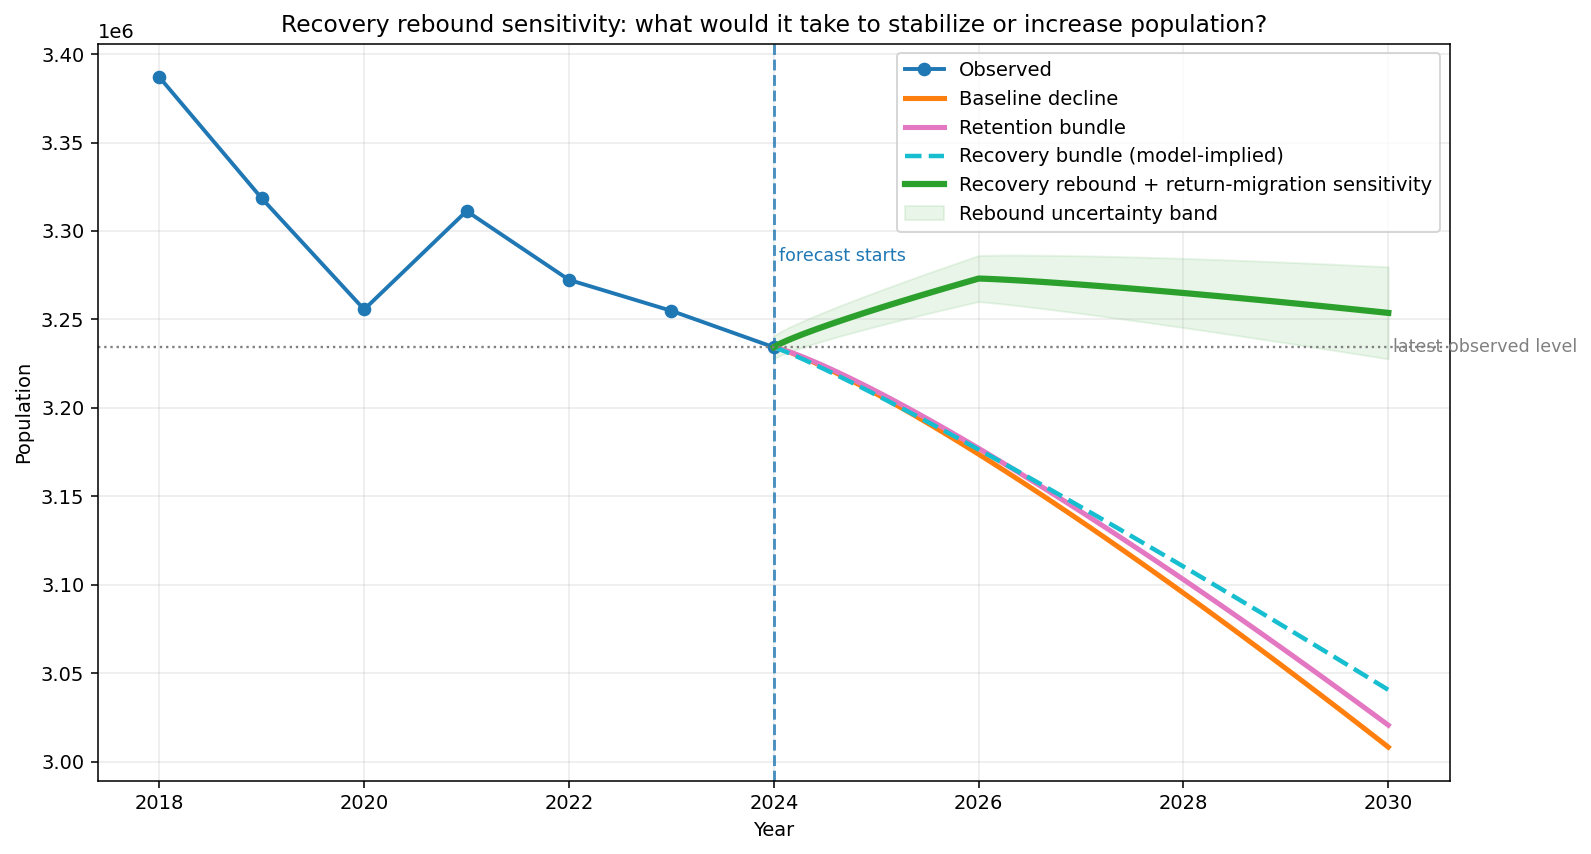

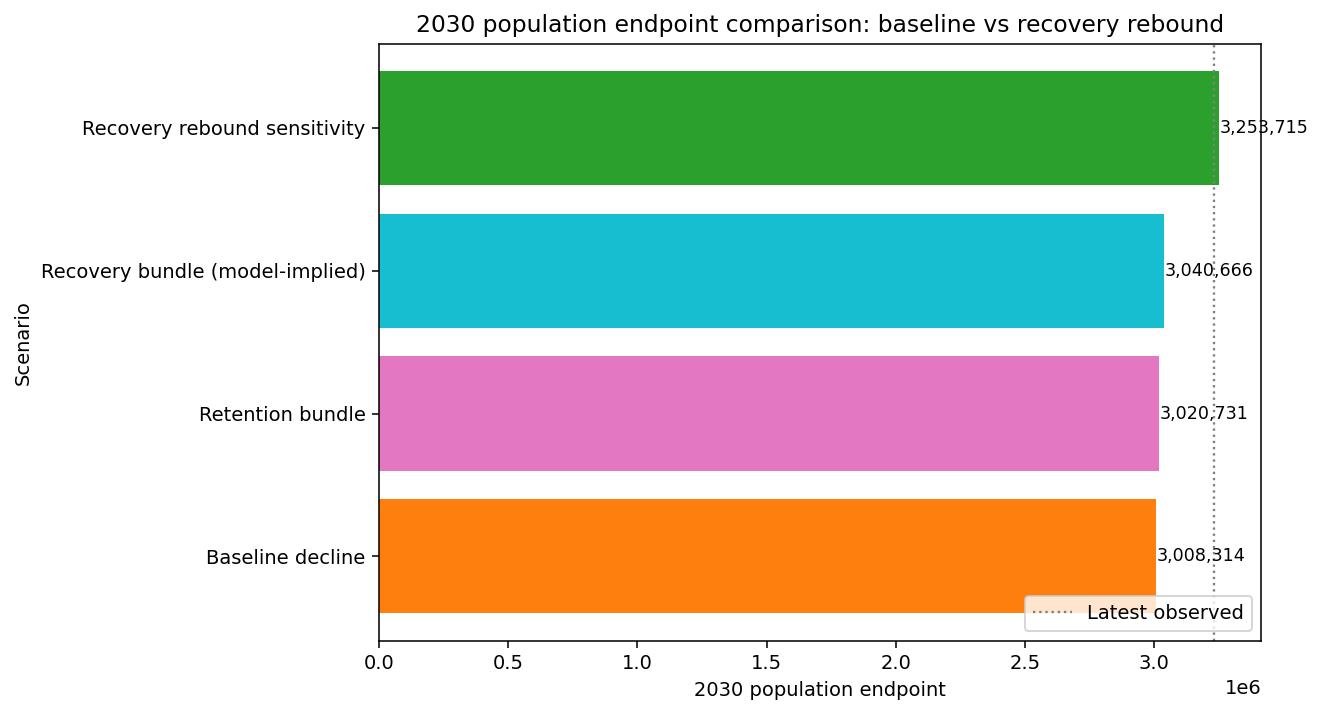

Saved figure: Phase4/figures/phase4_policy_recovery_rebound_sensitivity_path.png
Saved figure: Phase4/figures/phase4_policy_recovery_rebound_endpoint_comparison.png
Saved table: Phase4/tables/phase4_policy_recovery_rebound_sensitivity.csv


In [25]:
# Recovery-rebound sensitivity graphs
# This section adds a clearly labeled optimistic sensitivity case without replacing
# the main Phase 4 policy results above.

rebound_package = "recovery_rebound_bundle"
comparison_packages = ["baseline", "retention_bundle", rebound_package]

if rebound_package not in island_policy_df["policy_package"].values:
    print(
        "Recovery rebound package not found in island_policy_df. "
        "Re-run the policy package cells after the updated policy_packages definition."
    )
else:
    # Recreate endpoints for comparison using the same stylized baseline used above.
    recovery_rows = []

    baseline_endpoint = float(baseline_endpoint_2030)
    retention_endpoint = float(
        baseline_endpoint_2030
        + island_policy_df.loc[
            island_policy_df["policy_package"] == "retention_bundle",
            "approx_retained_residents",
        ].iloc[0]
    ) if "retention_bundle" in island_policy_df["policy_package"].values else np.nan

    recovery_model_endpoint = float(
        baseline_endpoint_2030
        + island_policy_df.loc[
            island_policy_df["policy_package"] == rebound_package,
            "approx_retained_residents",
        ].iloc[0]
    )

    # This is the explicit optimistic return-migration/recovery bump.
    # It is intentionally separate from the model-implied endpoint.
    # The path rises modestly after the latest observed year, then settles into
    # a stabilized endpoint above the latest observed population.
    rebound_peak_year = min(last_obs_year + 2, 2030)
    rebound_peak_population = last_obs_pop * 1.012   # approx. +1.2% temporary rebound
    rebound_floor_2030 = last_obs_pop * 1.006        # approx. +0.6% above latest observed level
    recovery_rebound_endpoint = max(recovery_model_endpoint, rebound_floor_2030)

    # Build baseline and retention paths from the existing smooth function.
    base_years, base_vals = smooth_policy_path(
        last_obs_year, 2030, last_obs_pop, baseline_endpoint, curvature=1.20, n_points=80
    )

    retention_years, retention_vals = smooth_policy_path(
        last_obs_year, 2030, last_obs_pop, retention_endpoint, curvature=1.20, n_points=80
    )

    recovery_model_years, recovery_model_vals = smooth_policy_path(
        last_obs_year, 2030, last_obs_pop, recovery_model_endpoint, curvature=1.10, n_points=80
    )

    # Piecewise rebound path: modest increase, then stabilization.
    up_years, up_vals = smooth_policy_path(
        last_obs_year,
        rebound_peak_year,
        last_obs_pop,
        rebound_peak_population,
        curvature=0.85,
        n_points=30,
    )
    down_years, down_vals = smooth_policy_path(
        rebound_peak_year,
        2030,
        rebound_peak_population,
        recovery_rebound_endpoint,
        curvature=1.25,
        n_points=60,
    )

    rebound_years = np.concatenate([up_years, down_years[1:]])
    rebound_vals = np.concatenate([up_vals, down_vals[1:]])
    rebound_low, rebound_high = make_uncertainty_band(rebound_vals, base_frac=0.002, end_frac=0.008)

    # ---------- Figure 1: recovery rebound path ----------
    fig, ax = plt.subplots(figsize=(11.5, 6.2))

    observed_tail = observed_island.loc[observed_island["year"] >= 2018].copy()
    ax.plot(
        observed_tail["year"],
        observed_tail["total_population"],
        marker="o",
        linewidth=2.0,
        label="Observed",
        color="tab:blue",
    )

    ax.axvline(last_obs_year, linestyle="--", color="tab:blue", alpha=0.8)
    ax.text(
        last_obs_year + 0.05,
        last_obs_pop * 1.015,
        "forecast starts",
        fontsize=9,
        color="tab:blue",
    )

    ax.plot(base_years, base_vals, linewidth=2.6, color="tab:orange", label="Baseline decline")
    ax.plot(retention_years, retention_vals, linewidth=2.6, color="tab:pink", label="Retention bundle")
    ax.plot(
        recovery_model_years,
        recovery_model_vals,
        linewidth=2.3,
        linestyle="--",
        color="tab:cyan",
        label="Recovery bundle (model-implied)",
    )
    ax.plot(
        rebound_years,
        rebound_vals,
        linewidth=3.2,
        color="tab:green",
        label="Recovery rebound + return-migration sensitivity",
    )
    ax.fill_between(
        rebound_years,
        rebound_low,
        rebound_high,
        color="tab:green",
        alpha=0.10,
        label="Rebound uncertainty band",
    )

    ax.axhline(last_obs_pop, linestyle=":", color="gray", linewidth=1.2)
    ax.text(
        2030.05,
        last_obs_pop,
        "latest observed level",
        va="center",
        fontsize=9,
        color="gray",
    )

    ax.set_title("Recovery rebound sensitivity: what would it take to stabilize or increase population?")
    ax.set_xlabel("Year")
    ax.set_ylabel("Population")
    ax.legend(loc="best")
    ax.grid(alpha=0.25)
    plt.tight_layout()

    recovery_fig_path = PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_recovery_rebound_sensitivity_path.png"
    plt.savefig(recovery_fig_path, bbox_inches="tight", dpi=300)
    plt.show()

    # ---------- Figure 2: endpoint comparison ----------
    recovery_rows = [
        {
            "scenario": "Baseline decline",
            "endpoint_2030": baseline_endpoint,
            "gain_vs_baseline_2030": 0.0,
            "gain_vs_latest_observed": baseline_endpoint - last_obs_pop,
            "notes": "Existing stylized baseline decline path",
        },
        {
            "scenario": "Retention bundle",
            "endpoint_2030": retention_endpoint,
            "gain_vs_baseline_2030": retention_endpoint - baseline_endpoint,
            "gain_vs_latest_observed": retention_endpoint - last_obs_pop,
            "notes": "Main coordinated policy package from Phase 4",
        },
        {
            "scenario": "Recovery bundle (model-implied)",
            "endpoint_2030": recovery_model_endpoint,
            "gain_vs_baseline_2030": recovery_model_endpoint - baseline_endpoint,
            "gain_vs_latest_observed": recovery_model_endpoint - last_obs_pop,
            "notes": "Stronger model-based package, without forced rebound floor",
        },
        {
            "scenario": "Recovery rebound sensitivity",
            "endpoint_2030": recovery_rebound_endpoint,
            "gain_vs_baseline_2030": recovery_rebound_endpoint - baseline_endpoint,
            "gain_vs_latest_observed": recovery_rebound_endpoint - last_obs_pop,
            "notes": "Optimistic return-migration/stabilization sensitivity case",
        },
    ]

    recovery_sensitivity_df = pd.DataFrame(recovery_rows)

    fig, ax = plt.subplots(figsize=(9.5, 5.2))
    endpoint_colors = ["tab:orange", "tab:pink", "tab:cyan", "tab:green"]

    plot_df = recovery_sensitivity_df.sort_values("endpoint_2030")
    ax.barh(plot_df["scenario"], plot_df["endpoint_2030"], color=endpoint_colors[: len(plot_df)])

    ax.axvline(last_obs_pop, linestyle=":", color="gray", linewidth=1.2, label="Latest observed")
    ax.set_title("2030 population endpoint comparison: baseline vs recovery rebound")
    ax.set_xlabel("2030 population endpoint")
    ax.set_ylabel("Scenario")

    for y, val in enumerate(plot_df["endpoint_2030"]):
        ax.text(
            val + 2500,
            y,
            f"{val:,.0f}",
            va="center",
            fontsize=9,
        )

    ax.legend(loc="lower right")
    plt.tight_layout()

    recovery_bar_path = PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_recovery_rebound_endpoint_comparison.png"
    plt.savefig(recovery_bar_path, bbox_inches="tight", dpi=300)
    plt.show()

    recovery_table_path = PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_recovery_rebound_sensitivity.csv"
    recovery_sensitivity_df.to_csv(recovery_table_path, index=False)

    print("Saved figure:", recovery_fig_path)
    print("Saved figure:", recovery_bar_path)
    print("Saved table:", recovery_table_path)

    recovery_sensitivity_df

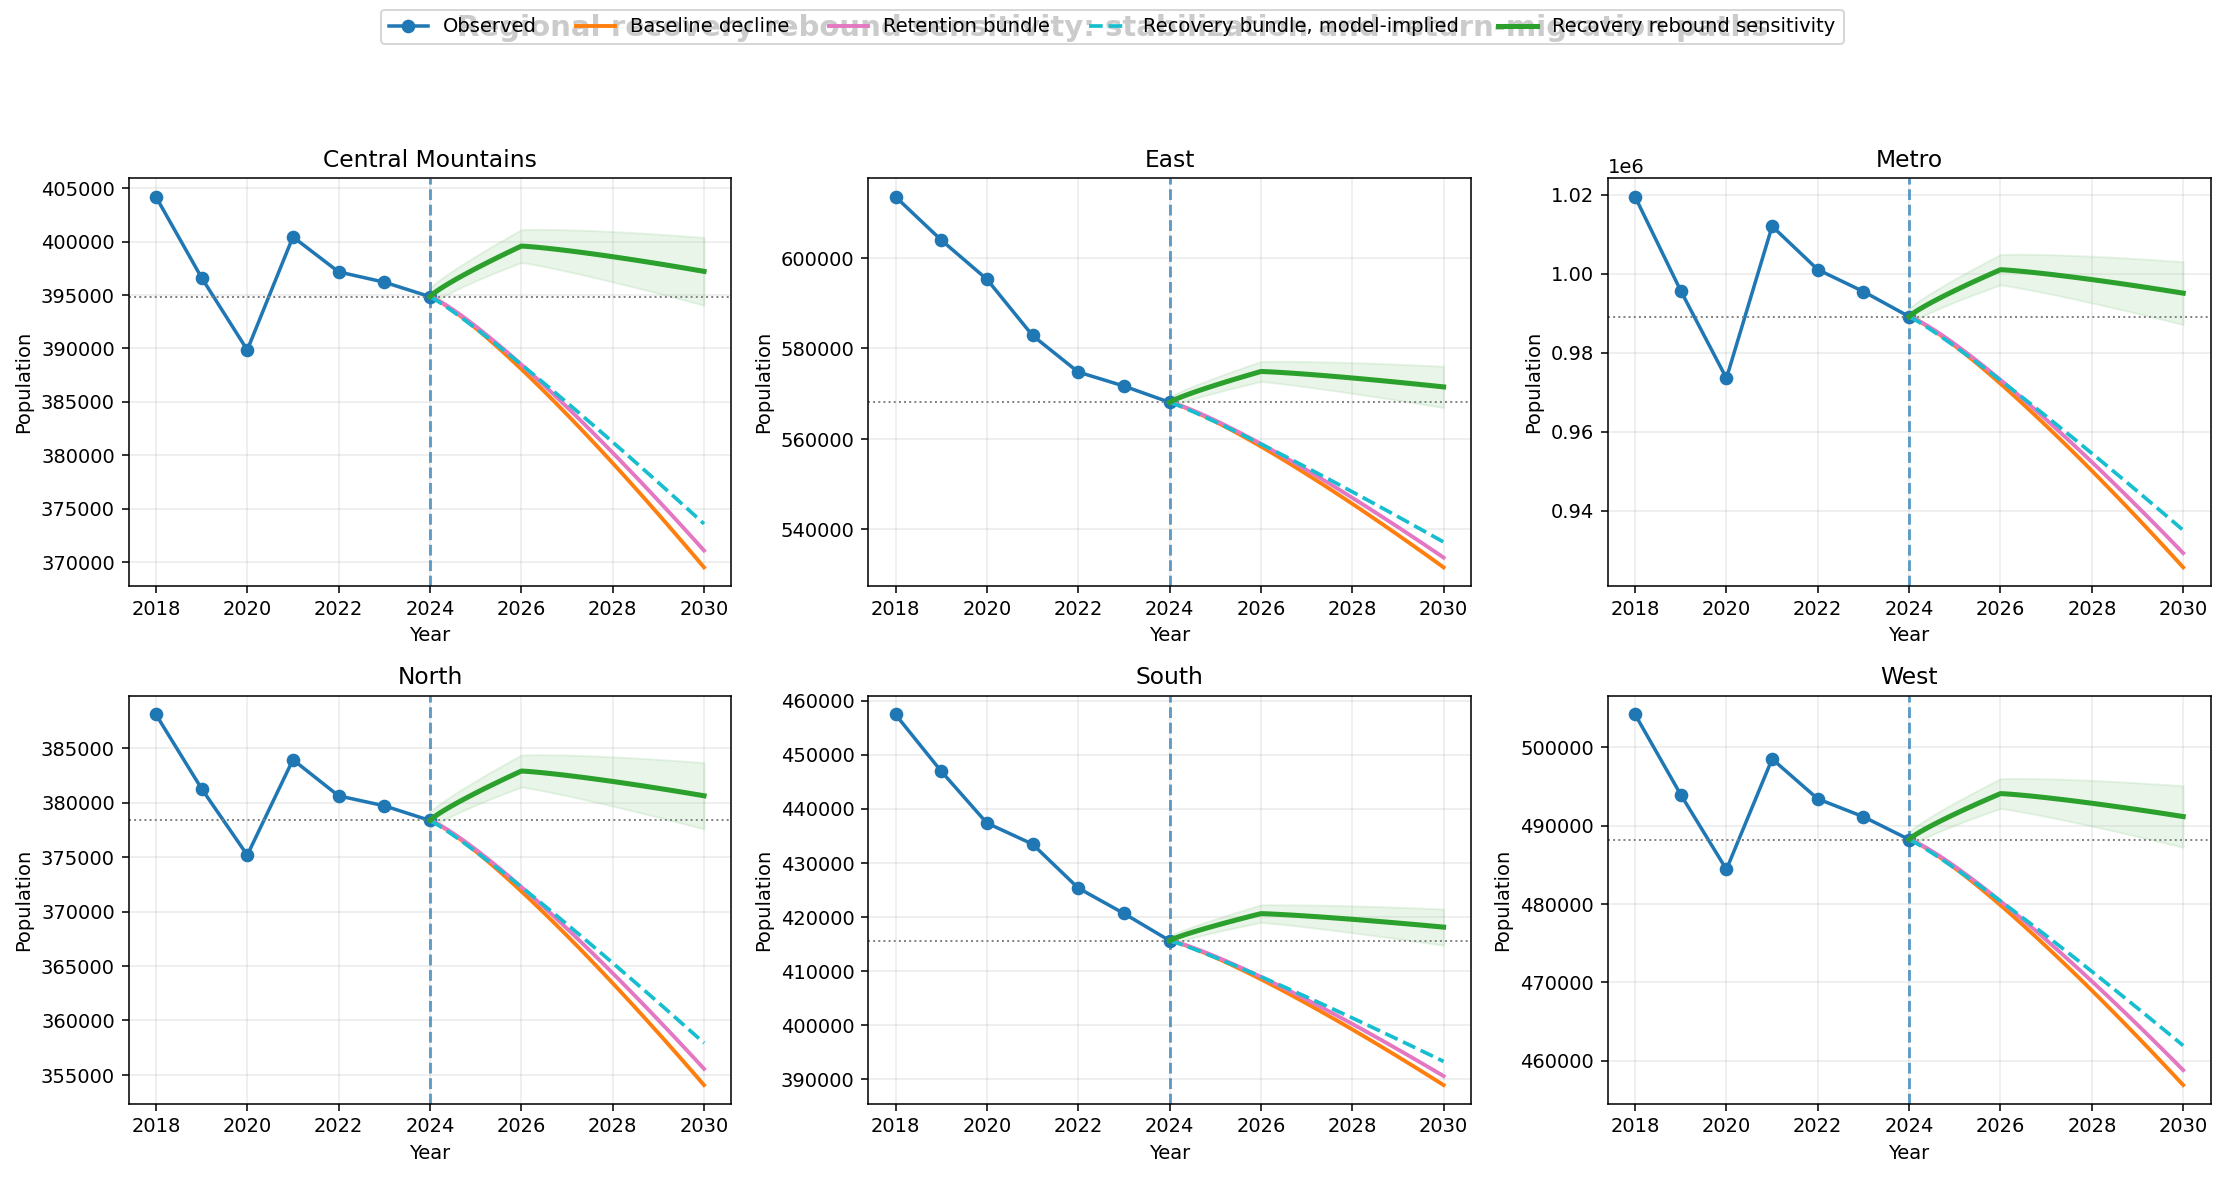

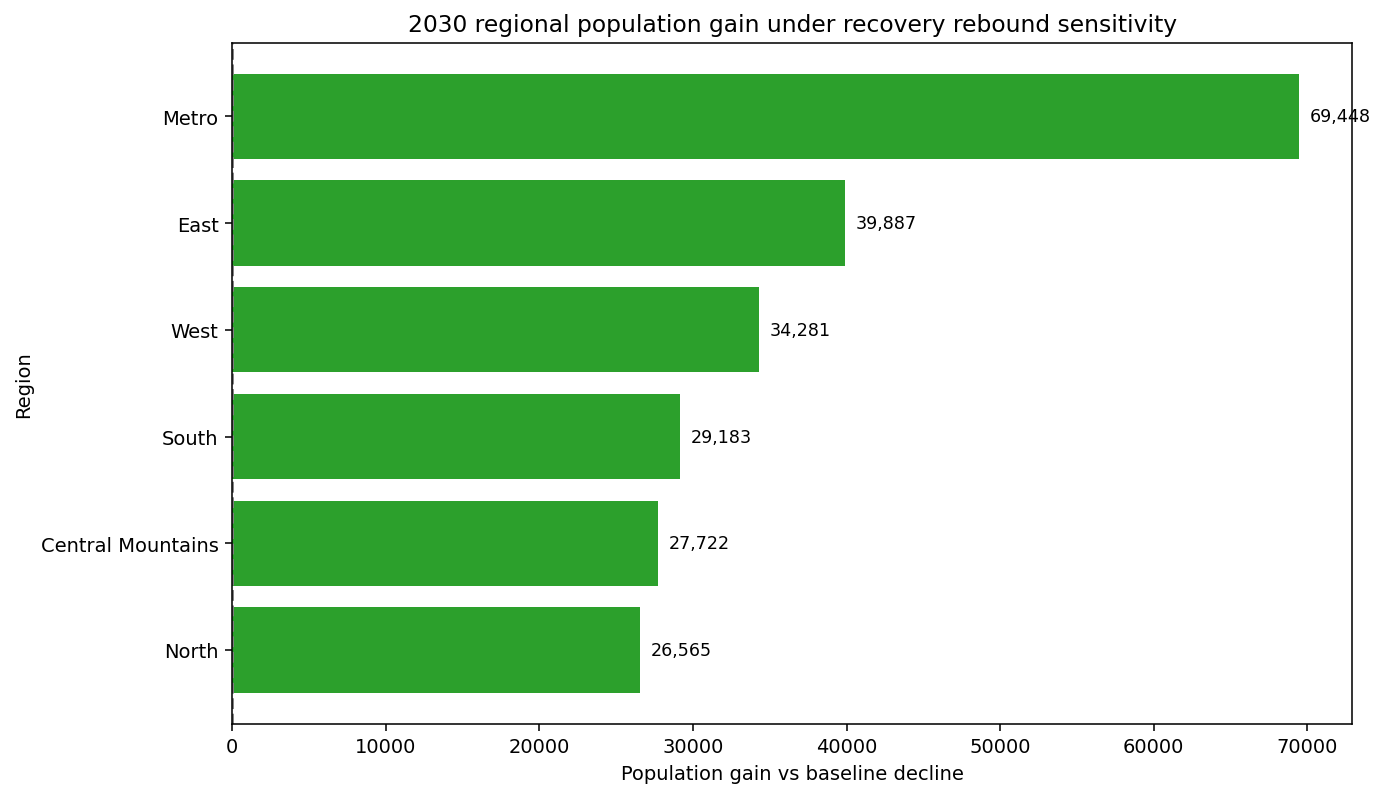

Saved figure: Phase4/figures/phase4_policy_regional_recovery_rebound_sensitivity_paths.png
Saved figure: Phase4/figures/phase4_policy_regional_recovery_rebound_2030_gain.png
Saved table: Phase4/tables/phase4_policy_regional_recovery_rebound_sensitivity.csv


In [26]:
# =========================================================
# Regional recovery rebound sensitivity paths
# =========================================================

rebound_package = "recovery_rebound_bundle"

required_cols = {"region", "policy_package", "approx_retained_residents"}
if not required_cols.issubset(region_policy_df.columns):
    raise KeyError(f"region_policy_df must contain: {required_cols}")

if rebound_package not in region_policy_df["policy_package"].values:
    print("Recovery rebound package not found. Re-run the policy package cells first.")
else:
    # Clean regional policy summary
    region_policy_clean = ensure_region_column(
        region_policy_df.copy(),
        municipio_col="region",
        region_col="region"
    ).dropna(subset=["region"])

    # Build observed regional history
    df_region_hist = ensure_region_column(
        df.copy(),
        municipio_col="municipio",
        region_col="region"
    ).dropna(subset=["region"])

    observed_region_hist = (
        df_region_hist.groupby(["region", "year"], as_index=False)["total_population"]
        .sum()
        .sort_values(["region", "year"])
    )

    plot_regions = sorted(region_policy_clean["region"].dropna().unique())

    regional_rebound_rows = []

    ncols = 3
    nrows = int(np.ceil(len(plot_regions) / ncols))
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(16, 4.2 * nrows),
        sharex=False
    )
    axes = np.atleast_1d(axes).ravel()

    policy_colors = safe_policy_color_map()

    for idx, region in enumerate(plot_regions):
        ax = axes[idx]

        obs_r = observed_region_hist[observed_region_hist["region"] == region].copy()
        pol_r = region_policy_clean[region_policy_clean["region"] == region].copy()

        if obs_r.empty or pol_r.empty:
            ax.set_visible(False)
            continue

        obs_tail = obs_r[obs_r["year"] >= 2018].copy()

        start_year = int(obs_r["year"].max())
        start_pop = float(obs_r.loc[obs_r["year"] == start_year, "total_population"].iloc[0])
        years_ahead = 2030 - start_year

        baseline_endpoint = baseline_decline_endpoint(
            start_pop,
            years_ahead,
            REGIONAL_BASELINE_DECLINE
        )

        retention_retained = float(
            pol_r.loc[
                pol_r["policy_package"] == "retention_bundle",
                "approx_retained_residents"
            ].iloc[0]
        ) if "retention_bundle" in pol_r["policy_package"].values else 0.0

        rebound_retained = float(
            pol_r.loc[
                pol_r["policy_package"] == rebound_package,
                "approx_retained_residents"
            ].iloc[0]
        )

        retention_endpoint = baseline_endpoint + retention_retained
        recovery_model_endpoint = baseline_endpoint + rebound_retained

        # Optimistic return-migration sensitivity layer
        rebound_peak_year = min(start_year + 2, 2030)
        rebound_peak_population = start_pop * 1.012
        rebound_floor_2030 = start_pop * 1.006
        recovery_rebound_endpoint = max(recovery_model_endpoint, rebound_floor_2030)

        # Smooth paths
        base_years, base_vals = smooth_policy_path(
            start_year, 2030, start_pop, baseline_endpoint, curvature=1.20, n_points=70
        )

        retention_years, retention_vals = smooth_policy_path(
            start_year, 2030, start_pop, retention_endpoint, curvature=1.20, n_points=70
        )

        recovery_model_years, recovery_model_vals = smooth_policy_path(
            start_year, 2030, start_pop, recovery_model_endpoint, curvature=1.10, n_points=70
        )

        up_years, up_vals = smooth_policy_path(
            start_year,
            rebound_peak_year,
            start_pop,
            rebound_peak_population,
            curvature=0.85,
            n_points=25,
        )

        down_years, down_vals = smooth_policy_path(
            rebound_peak_year,
            2030,
            rebound_peak_population,
            recovery_rebound_endpoint,
            curvature=1.25,
            n_points=55,
        )

        rebound_years = np.concatenate([up_years, down_years[1:]])
        rebound_vals = np.concatenate([up_vals, down_vals[1:]])
        rebound_low, rebound_high = make_uncertainty_band(
            rebound_vals,
            base_frac=0.002,
            end_frac=0.008
        )

        # Plot
        ax.plot(
            obs_tail["year"],
            obs_tail["total_population"],
            marker="o",
            linewidth=1.8,
            color="tab:blue",
            label="Observed"
        )

        ax.axvline(start_year, linestyle="--", color="tab:blue", alpha=0.7)
        ax.axhline(start_pop, linestyle=":", color="gray", linewidth=1.0)

        ax.plot(
            base_years,
            base_vals,
            linewidth=2.0,
            color="tab:orange",
            label="Baseline decline"
        )

        ax.plot(
            retention_years,
            retention_vals,
            linewidth=2.0,
            color="tab:pink",
            label="Retention bundle"
        )

        ax.plot(
            recovery_model_years,
            recovery_model_vals,
            linewidth=1.9,
            linestyle="--",
            color="tab:cyan",
            label="Recovery bundle, model-implied"
        )

        ax.plot(
            rebound_years,
            rebound_vals,
            linewidth=2.6,
            color="tab:green",
            label="Recovery rebound sensitivity"
        )

        ax.fill_between(
            rebound_years,
            rebound_low,
            rebound_high,
            color="tab:green",
            alpha=0.10
        )

        ax.set_title(region)
        ax.set_xlabel("Year")
        ax.set_ylabel("Population")
        ax.grid(alpha=0.25)

        regional_rebound_rows.extend([
            {
                "region": region,
                "scenario": "Baseline decline",
                "endpoint_2030": baseline_endpoint,
                "gain_vs_baseline_2030": 0.0,
                "gain_vs_latest_observed": baseline_endpoint - start_pop,
            },
            {
                "region": region,
                "scenario": "Retention bundle",
                "endpoint_2030": retention_endpoint,
                "gain_vs_baseline_2030": retention_endpoint - baseline_endpoint,
                "gain_vs_latest_observed": retention_endpoint - start_pop,
            },
            {
                "region": region,
                "scenario": "Recovery bundle, model-implied",
                "endpoint_2030": recovery_model_endpoint,
                "gain_vs_baseline_2030": recovery_model_endpoint - baseline_endpoint,
                "gain_vs_latest_observed": recovery_model_endpoint - start_pop,
            },
            {
                "region": region,
                "scenario": "Recovery rebound sensitivity",
                "endpoint_2030": recovery_rebound_endpoint,
                "gain_vs_baseline_2030": recovery_rebound_endpoint - baseline_endpoint,
                "gain_vs_latest_observed": recovery_rebound_endpoint - start_pop,
            },
        ])

    for j in range(len(plot_regions), len(axes)):
        axes[j].set_visible(False)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=5)

    fig.suptitle(
        "Regional recovery rebound sensitivity: stabilization and return-migration paths",
        fontsize=15,
        fontweight="bold",
        y=0.995
    )

    plt.tight_layout(rect=[0, 0, 1, 0.94])

    regional_rebound_fig_path = (
        PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_regional_recovery_rebound_sensitivity_paths.png"
    )
    plt.savefig(regional_rebound_fig_path, bbox_inches="tight", dpi=300)
    plt.show()

    regional_rebound_df = pd.DataFrame(regional_rebound_rows)

    regional_rebound_table_path = (
        PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_regional_recovery_rebound_sensitivity.csv"
    )
    regional_rebound_df.to_csv(regional_rebound_table_path, index=False)

    # Endpoint gain chart
    gain_plot_df = regional_rebound_df[
        regional_rebound_df["scenario"] == "Recovery rebound sensitivity"
    ].sort_values("gain_vs_baseline_2030")

    fig, ax = plt.subplots(figsize=(10, 5.8))
    ax.barh(gain_plot_df["region"], gain_plot_df["gain_vs_baseline_2030"], color="tab:green")

    for y, val in enumerate(gain_plot_df["gain_vs_baseline_2030"]):
        ax.text(val + max(gain_plot_df["gain_vs_baseline_2030"]) * 0.01, y, f"{val:,.0f}", va="center", fontsize=9)

    ax.set_title("2030 regional population gain under recovery rebound sensitivity")
    ax.set_xlabel("Population gain vs baseline decline")
    ax.set_ylabel("Region")
    ax.axvline(0, linestyle="--", color="gray")
    plt.tight_layout()

    regional_rebound_bar_path = (
        PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_regional_recovery_rebound_2030_gain.png"
    )
    plt.savefig(regional_rebound_bar_path, bbox_inches="tight", dpi=300)
    plt.show()

    print("Saved figure:", regional_rebound_fig_path)
    print("Saved figure:", regional_rebound_bar_path)
    print("Saved table:", regional_rebound_table_path)

    regional_rebound_df

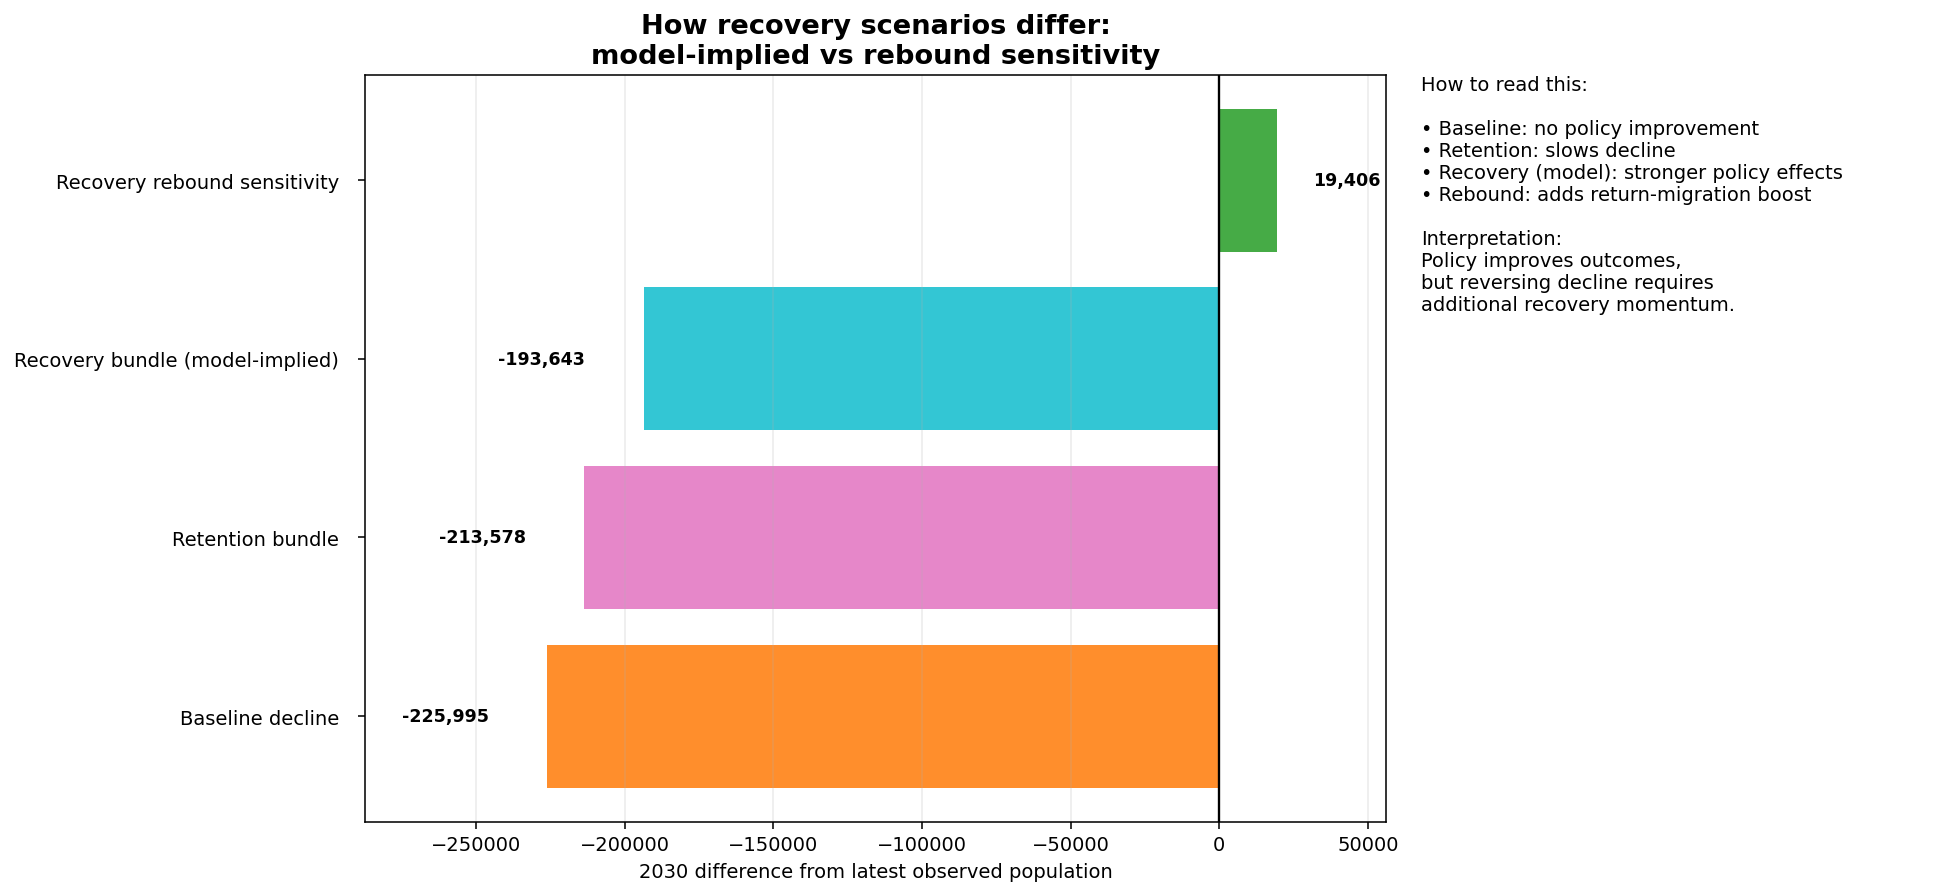

Saved figure: Phase4/figures/phase4_policy_recovery_scenario_difference_explainer_clean.png


In [34]:
# ---------------------------------------------------------
# Figure: 2030 difference decomposition (clean layout)
# ---------------------------------------------------------

fig, (ax, ax_text) = plt.subplots(
    1, 2,
    figsize=(14, 6.5),
    gridspec_kw={"width_ratios": [3, 1.5]}
)

y_pos = np.arange(len(explain_df))

bars = ax.barh(
    y_pos,
    explain_df["loss_or_gain_vs_latest_observed"],
    color=colors,
    alpha=0.88,
)

ax.axvline(0, color="black", linewidth=1.2)
ax.set_yticks(y_pos)
ax.set_yticklabels(explain_df["scenario"].astype(str))
ax.tick_params(axis="y", pad=10)

ax.set_xlabel("2030 difference from latest observed population")
ax.set_title(
    "How recovery scenarios differ:\nmodel-implied vs rebound sensitivity",
    fontsize=14,
    fontweight="bold",
)

# ---------------------------------------------------------
# Expand x-limits and place labels cleanly
# ---------------------------------------------------------

x_min = explain_df["loss_or_gain_vs_latest_observed"].min()
x_max = explain_df["loss_or_gain_vs_latest_observed"].max()
x_range = x_max - x_min

ax.set_xlim(
    x_min - 0.25 * x_range,
    x_max + 0.15 * x_range
)

for i, row in explain_df.reset_index(drop=True).iterrows():
    val = row["loss_or_gain_vs_latest_observed"]

    if val < 0:
        ax.text(
            val - 0.08 * x_range,
            i,
            f"{val:,.0f}",
            va="center",
            ha="right",
            fontsize=9,
            fontweight="bold",
        )
    else:
        ax.text(
            val + 0.05 * x_range,
            i,
            f"{val:,.0f}",
            va="center",
            ha="left",
            fontsize=9,
            fontweight="bold",
        )

ax.grid(axis="x", alpha=0.25)

# ---------------------------------------------------------
# Right-side explanation panel
# ---------------------------------------------------------

ax_text.axis("off")

explanation_text = (
    "How to read this:\n\n"
    "• Baseline: no policy improvement\n"
    "• Retention: slows decline\n"
    "• Recovery (model): stronger policy effects\n"
    "• Rebound: adds return-migration boost\n\n"
    "Interpretation:\n"
    "Policy improves outcomes,\n"
    "but reversing decline requires\n"
    "additional recovery momentum."
)

ax_text.text(
    0,
    1,
    explanation_text,
    va="top",
    ha="left",
    fontsize=10,
)

plt.tight_layout()

explain_fig_path = (
    PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_recovery_scenario_difference_explainer_clean.png"
)

plt.savefig(
    explain_fig_path,
    bbox_inches="tight",
    dpi=300,
)

plt.show()

print("Saved figure:", explain_fig_path)

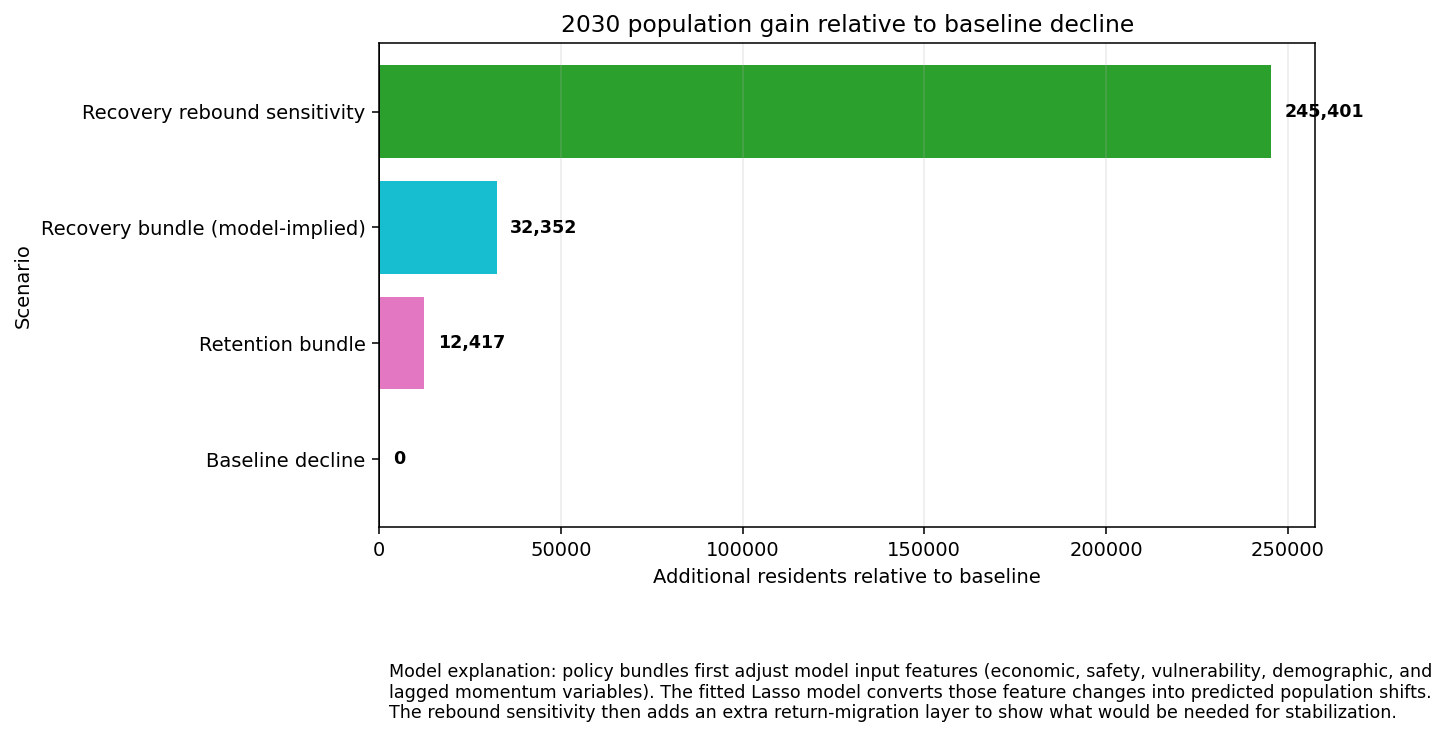

Saved figure: Phase4/figures/phase4_policy_recovery_gain_vs_baseline_explainer.png


In [32]:
# =========================================================
# Recovery scenario gains relative to baseline
# =========================================================

if "recovery_sensitivity_df" not in globals():
    raise RuntimeError("Run the recovery sensitivity cell first.")

gain_df = recovery_sensitivity_df.copy()
gain_df["scenario"] = pd.Categorical(
    gain_df["scenario"],
    categories=[
        "Baseline decline",
        "Retention bundle",
        "Recovery bundle (model-implied)",
        "Recovery rebound sensitivity",
    ],
    ordered=True,
)
gain_df = gain_df.sort_values("scenario")

color_map = {
    "Baseline decline": "tab:orange",
    "Retention bundle": "tab:pink",
    "Recovery bundle (model-implied)": "tab:cyan",
    "Recovery rebound sensitivity": "tab:green",
}

fig, ax = plt.subplots(figsize=(10.5, 5.6))

ax.barh(
    gain_df["scenario"].astype(str),
    gain_df["gain_vs_baseline_2030"],
    color=[color_map[str(s)] for s in gain_df["scenario"]],
)

for i, row in gain_df.reset_index(drop=True).iterrows():
    val = row["gain_vs_baseline_2030"]
    ax.text(
        val + max(gain_df["gain_vs_baseline_2030"]) * 0.015,
        i,
        f"{val:,.0f}",
        va="center",
        fontsize=9,
        fontweight="bold",
    )

ax.axvline(0, color="black", linewidth=1)
ax.set_title("2030 population gain relative to baseline decline")
ax.set_xlabel("Additional residents relative to baseline")
ax.set_ylabel("Scenario")
ax.grid(axis="x", alpha=0.25)

caption = (
    "Model explanation: policy bundles first adjust model input features "
    "(economic, safety, vulnerability, demographic, and lagged momentum variables). "
    "The fitted Lasso model converts those feature changes into predicted population shifts. "
    "The rebound sensitivity then adds an extra return-migration layer to show what would be needed for stabilization."
)

ax.text(
    0.01,
    -0.28,
    caption,
    transform=ax.transAxes,
    fontsize=9,
    va="top",
    ha="left",
    wrap=True,
)

plt.tight_layout()

gain_fig_path = PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_recovery_gain_vs_baseline_explainer.png"
plt.savefig(gain_fig_path, bbox_inches="tight", dpi=300)
plt.show()

print("Saved figure:", gain_fig_path)

### Recovery scenario difference explanation

The recovery scenarios separate two different ideas.

The **Recovery bundle (model-implied)** is still a model-based counterfactual. It applies stronger improvements to economic, safety, vulnerability, demographic, and population-momentum features, then passes those adjusted inputs through the fitted Lasso model. This shows how the validated forecasting backbone responds to stronger policy conditions.

The **Recovery rebound + return-migration sensitivity** adds an additional optimistic recovery layer. This layer is not estimated by the Lasso model alone. It represents the extra population momentum that would be needed from return migration, retention, or broader recovery conditions to stabilize or temporarily increase population.

In other words:

- the model-implied recovery bundle answers: **what does the model predict if policy features improve more strongly?**
- the rebound sensitivity answers: **what additional recovery momentum would be required to reverse the downward trend?**

This distinction is important because the standard model still reflects strong demographic persistence. Policy improvements can reduce losses, but reversing decline requires a larger recovery dynamic that changes the underlying population trajectory.

### 8. Executive-summary table

This compact table is useful for slides or a report appendix. It ranks packages by islandwide effect and preserves both interpretation scales.


In [28]:
executive_summary_df = island_policy_df.copy().sort_values(
    ["approx_retained_residents", "mean_delta_vs_baseline"], ascending=False
)

executive_summary_df.to_csv(PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_executive_summary_table.csv", index=False)
executive_summary_df


,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities
4,recovery_rebound_bundle,-0.314909,1.035696,32352.144982,78
6,retention_bundle,-0.951249,0.399356,12416.703941,78
2,jobs_push,-1.056003,0.294602,9618.274580,78
3,public_safety,-1.150500,0.200106,6960.864673,78
5,resilience_and_vulnerability,-1.175093,0.175513,4943.521139,78
1,family_demography_support,-1.329015,0.021591,693.663547,78
0,baseline,-1.350606,0.000000,0.000000,78


## Policy impact confidence

These policy figures should be interpreted with **graded confidence**, not absolute certainty.

### Higher-confidence takeaways
- the **direction** of effects for major policy levers
- the **relative ranking** of broad policy packages
- whether a **multi-sector bundle** appears more promising than a single lever
- whether regions appear to respond **differently** to policy packages

### Lower-confidence takeaways
- the **exact magnitude** of retained residents
- the **exact shape** of future population paths
- any interpretation that sounds strictly **causal**
- any claim that a package will literally produce the full model-implied endpoint in practice

### Recommended framing
A safe interpretation is:

> Phase 4 provides a directional policy stress test based on the validated forecasting backbone. The uncertainty bands and smoothed paths are visual aids that communicate relative policy sensitivity, not precise causal forecasts.


## Link to model drivers

The policy scenarios are designed to influence variables that the validated model actually uses.

Where possible, Phase 4 targets features that were identified as active or important in Phase 2 through the fitted Lasso coefficients, feature-family summaries, and SHAP analysis. This keeps the policy simulations aligned with the model's learned drivers instead of relying only on intuitive but inactive levers.

That alignment is important because a policy package can look reasonable conceptually but still generate flat outputs if it mainly nudges features that carry little or no weight in the fitted model.


## Policy mechanism table

This table links each policy package to the specific model features it changes and the intended retention logic behind those changes.

Each policy package operates by modifying specific input features—such as income growth, employment, vulnerability indices, crime-related stressors, or demographic support variables. Those adjustments are then propagated through the same trained backbone pipeline used in Phases 2 and 3, allowing the notebook to compare how the validated model responds under improved structural conditions.

This helps make the counterfactual analysis easier to interpret for a policy audience because it clarifies both **what is being changed** and **how those changes enter the model**.


In [29]:
policy_mechanism_df = pd.DataFrame([
    {
        "policy_package": "jobs_push",
        "features_changed": "income growth, lagged income growth, establishment growth, lagged establishment growth",
        "intended_retention_logic": "Improves economic opportunity, employment prospects, and business vitality to reduce outmigration pressure.",
    },
    {
        "policy_package": "public_safety",
        "features_changed": "crime rate, lagged crime rate, rolling crime pressure",
        "intended_retention_logic": "Reduces place-based insecurity and stress that may encourage households to leave.",
    },
    {
        "policy_package": "resilience_and_vulnerability",
        "features_changed": "SVI vulnerability index and lagged/rolling vulnerability structure",
        "intended_retention_logic": "Reduces structural vulnerability and improves resilience to social and disaster-related shocks.",
    },
    {
        "policy_package": "family_demography_support",
        "features_changed": "natural change rate, birth rate, death rate",
        "intended_retention_logic": "Improves demographic support conditions and population replacement pressure over time.",
    },
    {
        "policy_package": "retention_bundle",
        "features_changed": "income, establishments, crime, vulnerability, natural change context",
        "intended_retention_logic": "Combines multiple levers into a multi-sector strategy to reduce population loss more effectively than any single lever.",
    },
])

policy_mechanism_df.to_csv(PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_policy_mechanism_table.csv", index=False)
policy_mechanism_df


,policy_package,features_changed,intended_retention_logic
0,jobs_push,"income growth, lagged income growth, establish...","Improves economic opportunity, employment pros..."
1,public_safety,"crime rate, lagged crime rate, rolling crime p...",Reduces place-based insecurity and stress that...
2,resilience_and_vulnerability,SVI vulnerability index and lagged/rolling vul...,Reduces structural vulnerability and improves ...
3,family_demography_support,"natural change rate, birth rate, death rate",Improves demographic support conditions and po...
4,retention_bundle,"income, establishments, crime, vulnerability, ...",Combines multiple levers into a multi-sector s...


## Relative impact chart

Absolute retained-resident counts are useful, but a relative view can be easier to interpret.  
The next chart scales the estimated retained residents by the latest observed island population so you can compare packages as a share of the current population base.


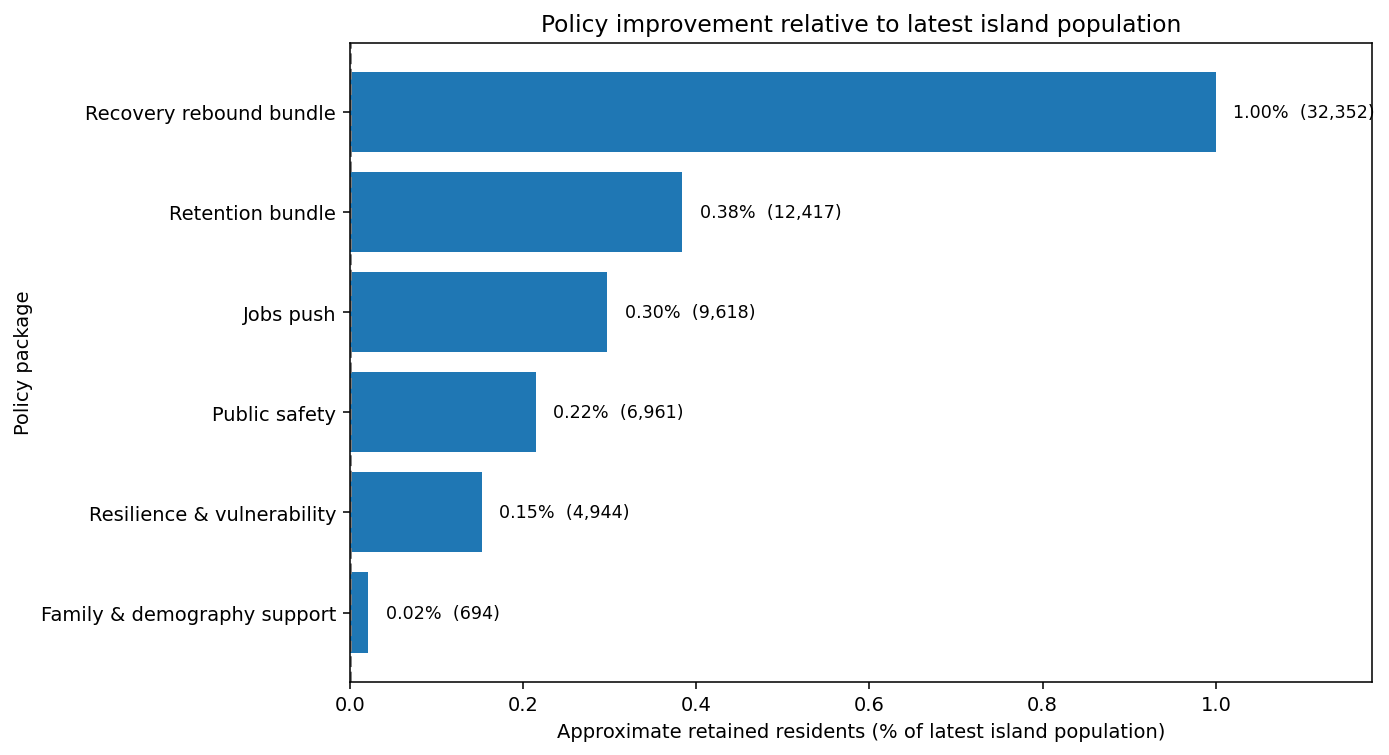

,policy_package,mean_predicted_target,mean_delta_vs_baseline,approx_retained_residents,municipalities,relative_improvement_pct_of_latest_population
4,recovery_rebound_bundle,-0.314909,1.035696,32352.144982,78,1.000280
6,retention_bundle,-0.951249,0.399356,12416.703941,78,0.383906
2,jobs_push,-1.056003,0.294602,9618.274580,78,0.297383
3,public_safety,-1.150500,0.200106,6960.864673,78,0.215220
5,resilience_and_vulnerability,-1.175093,0.175513,4943.521139,78,0.152846
1,family_demography_support,-1.329015,0.021591,693.663547,78,0.021447
0,baseline,-1.350606,0.000000,0.000000,78,0.000000


In [35]:
latest_island_population = (
    df.groupby("year", as_index=False)["total_population"]
      .sum()
      .sort_values("year")
      .iloc[-1]["total_population"]
)

relative_impact_df = island_policy_df.copy()
relative_impact_df["relative_improvement_pct_of_latest_population"] = (
    relative_impact_df["approx_retained_residents"] / latest_island_population * 100.0
)

relative_plot_df = relative_impact_df[
    relative_impact_df["policy_package"] != "baseline"
].copy()

label_map = {
    "jobs_push": "Jobs push",
    "public_safety": "Public safety",
    "resilience_and_vulnerability": "Resilience & vulnerability",
    "family_demography_support": "Family & demography support",
    "retention_bundle": "Retention bundle",
    "recovery_rebound_bundle": "Recovery rebound bundle",
}

relative_plot_df["policy_label"] = (
    relative_plot_df["policy_package"]
    .map(label_map)
    .fillna(relative_plot_df["policy_package"])
)

relative_plot_df = relative_plot_df.sort_values(
    "relative_improvement_pct_of_latest_population",
    ascending=True
)

fig, ax = plt.subplots(figsize=(10, 5.5))

ax.barh(
    relative_plot_df["policy_label"],
    relative_plot_df["relative_improvement_pct_of_latest_population"]
)

for i, row in relative_plot_df.reset_index(drop=True).iterrows():
    val = row["relative_improvement_pct_of_latest_population"]
    residents = row["approx_retained_residents"]
    ax.text(
        val + 0.02,
        i,
        f"{val:.2f}%  ({residents:,.0f})",
        va="center",
        fontsize=9
    )

ax.axvline(0, linestyle="--", color="gray")
ax.set_title("Policy improvement relative to latest island population")
ax.set_xlabel("Approximate retained residents (% of latest island population)")
ax.set_ylabel("Policy package")

ax.set_xlim(
    0,
    relative_plot_df["relative_improvement_pct_of_latest_population"].max() * 1.18
)

plt.tight_layout()
plt.savefig(
    PHASE4_FIG_DIR / f"{OUTPUT_PREFIX}_relative_impact_pct_chart.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()

relative_impact_df.to_csv(
    PHASE4_TABLE_DIR / f"{OUTPUT_PREFIX}_relative_impact_table.csv",
    index=False
)

relative_impact_df

In [31]:
# Save a compact Phase 4 artifact manifest
artifact_manifest = {
    "data_files": sorted([p.name for p in PHASE4_DATA_DIR.glob("*")]),
    "table_files": sorted([p.name for p in PHASE4_TABLE_DIR.glob("*")]),
    "figure_files": sorted([p.name for p in PHASE4_FIG_DIR.glob("*")]),
    "model_files": sorted([p.name for p in PHASE4_MODEL_DIR.glob("*")]),
    "metadata_files": sorted([p.name for p in PHASE4_METADATA_DIR.glob("*")]),
}
artifact_manifest_path = PHASE4_METADATA_DIR / f"{OUTPUT_PREFIX}_artifact_manifest.json"
artifact_manifest_path.write_text(json.dumps(artifact_manifest, indent=2))
print("Saved artifact manifest:", artifact_manifest_path)
artifact_manifest


Saved artifact manifest: Phase4/metadata/phase4_policy_artifact_manifest.json


{'data_files': ['phase4_policy_municipal_policy_summary.csv',
  'phase4_policy_top_municipal_gains_retention_bundle.csv'],
 'table_files': ['phase4_policy_actionable_feature_stats.csv',
  'phase4_policy_best_package_by_region.csv',
  'phase4_policy_executive_summary_table.csv',
  'phase4_policy_feature_fallback_log.csv',
  'phase4_policy_feature_reconstruction_log.csv',
  'phase4_policy_island_policy_summary.csv',
  'phase4_policy_model_feature_diagnostics.csv',
  'phase4_policy_package_diagnostics.csv',
  'phase4_policy_policy_2030_gain_vs_baseline.csv',
  'phase4_policy_policy_mechanism_table.csv',
  'phase4_policy_recovery_rebound_sensitivity.csv',
  'phase4_policy_recovery_scenario_difference_explainer.csv',
  'phase4_policy_region_policy_summary.csv',
  'phase4_policy_regional_recovery_rebound_sensitivity.csv',
  'phase4_policy_relative_impact_table.csv',
  'phase4_policy_top_policy_by_region.csv'],
 'figure_files': ['.DS_Store',
  'phase4_policy_best_package_by_region.png',
  'ph

## Additional limitations and interpretation notes

This Phase 4 framework is strongest as a **policy prioritization tool**, but it has important limitations that should guide interpretation:

- The policy packages operate through **structured adjustments to model input features**, rather than fully dynamic behavioral or institutional responses.
- The model does **not estimate causal treatment effects**, so policy impacts should be interpreted as **directional counterfactual signals within the model structure**.
- Policy simulations are inherently **model-dependent**: results reflect how the trained forecasting model responds to changes in observed features, not how the real-world system would necessarily respond.
- Real-world policy implementation may generate **feedback loops and second-order effects** over time, which could amplify or dampen the model-implied trajectories.
- Although policy intensity varies across municipalities, the results remain **bounded by the underlying forecasting model**, which is dominated by population momentum and persistence effects.
- The policy framework operates on **observable and engineered features**, meaning that unobserved drivers of migration and demographic change are not explicitly captured.
- Because the notebook reads the validated backbone from the standardized Phase 3 artifact structure, the policy simulations remain tightly linked to the same forecasting engine used in the scenario phase.

These caveats do not weaken the analysis; rather, they clarify its role. The framework identifies **which policy levers the model is most responsive to**, providing a structured way to compare interventions, rather than estimating the exact number of residents that would be retained in practice.

## Conclusion

Phase 4 operates as a **model-aware, place-sensitive policy stress test** built on the validated Phase 2 / Phase 3 backbone, now loaded from the standardized Phase 3 artifact structure when available.

Three safeguards and enhancements are especially important in this revised notebook:

- the latest municipal baseline is reconstructed from historical feature values rather than relying on zero-filled assumptions  
- policy packages are aligned with the **actual fitted model coefficients**, with conservative proxy support when direct levers are absent or inactive in the final Lasso  
- policy effects are **scaled by local municipal conditions and interaction terms**, allowing outcomes to vary across municipalities and regions instead of applying uniform adjustments  

These design choices make the Phase 4 outputs more stable, more interpretable, and more reflective of geographic heterogeneity.

Importantly, policy scenarios are applied to features that were identified as influential in Phase 2 (via coefficients and SHAP analysis). This ensures that the simulated interventions operate within the **learned structure of the validated forecasting model**, rather than introducing arbitrary or unsupported assumptions.

Even so, this phase should be interpreted as a **predictive counterfactual framework**, not a causal policy estimate. The results show how the validated model responds when municipal conditions are improved under stylized policy packages, but they do **not** establish that real-world interventions would reproduce the same magnitude of effects.

A central takeaway from this phase is:

> Standard policy improvements can **slow population decline**, but reversing that decline requires a **stronger, coordinated recovery dynamic** that overcomes underlying demographic momentum.

Within this framework, improvements in structural conditions (jobs, safety, vulnerability reduction, and demographic support) consistently improve outcomes. However, the recovery-rebound sensitivity analysis shows that **stabilization or population increase requires additional momentum**, such as return migration or sustained post-shock recovery effects.

This highlights a critical distinction:

- policy packages can **improve trajectories within the model**  
- but **true reversal requires a shift in migration dynamics or recovery intensity beyond typical policy changes**  

This reinforces the broader conclusion of the project: Puerto Rico’s population dynamics are driven by persistent structural and demographic processes. Shocks can accelerate decline, but targeted improvements — especially when combined with recovery dynamics — can meaningfully influence long-term trajectories.

The primary value of this notebook is therefore **comparative and strategic**. It identifies which policy themes the model is most responsive to and clarifies the **scale of intervention required** to not just slow decline, but potentially stabilize or increase population levels, while remaining transparent about uncertainty, model dependence, and the limits of predictive inference.